<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Maria_download_ReBeatICG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Descarga de datos

In [2]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

###Algoritmo general

In [3]:
pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.1/693.1 kB 15.9 MB/s eta 0:00:00


Vamos a modificar el código para que se realice sobre el ICG anotado y así podamos visualizar los puntos característicos B, C , X, O; y además, vamos a hacer el código más robusto para que funcione bien cuando se trate con los paciente 5 y 16 en estado CW ya que como se especifica en la información proporcionada por ReBeat no se tienen anotaciones en estos dos casos.

In [4]:
import scipy.io as sio
import numpy as np
import pandas as pd
import neurokit2 as nk
import os
import matplotlib.pyplot as plt

# Parámetros
fs = 250
pre_r = int(0.15 * fs)
post_r = int(0.6 * fs)
conditions = ['CW', 'BL']
num_patients = 24

# Lista para almacenar segmentos
all_segments = []

for patient_id in range(1, num_patients + 1):
    for condition in conditions:
        try:
            # Rutas
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{patient_id}_task_{condition}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{patient_id}_task_{condition}.mat'

            # Comprobar si los archivos existen
            if not os.path.exists(path_filtered):
                print(f"Archivo filtrado NO encontrado: {path_filtered}")
                continue
            if not os.path.exists(path_annotation):
                print(f"Archivo de anotaciones NO encontrado (pero no crítico): {path_annotation}")
                #Este paso se realiza para que CW con los pacientes 5 y 16 sea igual de robusto.

            # Cargar ECG y ICG filtrados
            data_filtered = sio.loadmat(path_filtered)
            ecg_filtered = data_filtered['ECG'].flatten().astype(np.float64)
            icg_filtered = data_filtered['ICG'].flatten().astype(np.float64)

            # Cargar anotaciones si existen (por si se quieren usar más adelante)
            if os.path.exists(path_annotation):
                annotation = sio.loadmat(path_annotation)
                annotations = annotation['annotPoints']
                B, C, X, O = annotations[:, 0], annotations[:, 1], annotations[:, 2], annotations[:, 3]

            # Procesar ECG para encontrar picos R
            ecg_signals, info = nk.ecg_process(ecg_filtered, sampling_rate=fs)
            r_peaks = info["ECG_R_Peaks"]

            # Segmentación de ICG alrededor de picos R
            for i, r_peak in enumerate(r_peaks):
                start_idx = r_peak - pre_r
                end_idx = r_peak + post_r
                if start_idx >= 0 and end_idx < len(icg_filtered):
                    segment = icg_filtered[start_idx:end_idx]
                    all_segments.append({
                        'Segment': segment,
                        'PatientID': patient_id,
                        'BeatNumber': i + 1,
                        'Condition': condition
                    })

        except Exception as e:
            print(f"Error con paciente {patient_id}, condición {condition}: {e}")

# Crear DataFrame
df_segments = pd.DataFrame(all_segments)

# Guardar en archivo para clustering
#df_segments.to_pickle('icg_segments_all.pkl')
#Este no lo puedo visualizar.

#Para poder abrirlo en excel y ver qué forma tiene.
df_segments.to_csv("icg_segments_all.csv", index=False)


Archivo de anotaciones NO encontrado (pero no crítico): /content/Annotations/Annotat_Subject_5_task_CW.mat
Archivo de anotaciones NO encontrado (pero no crítico): /content/Annotations/Annotat_Subject_16_task_CW.mat


###Algoritmo de delineación de puntos característicos  basado en el paper de ReBeatICG:

*Para comprobar que el algoritmo está ubicando el punto en el lugar óptimo he implementado un plot de un segmento random.

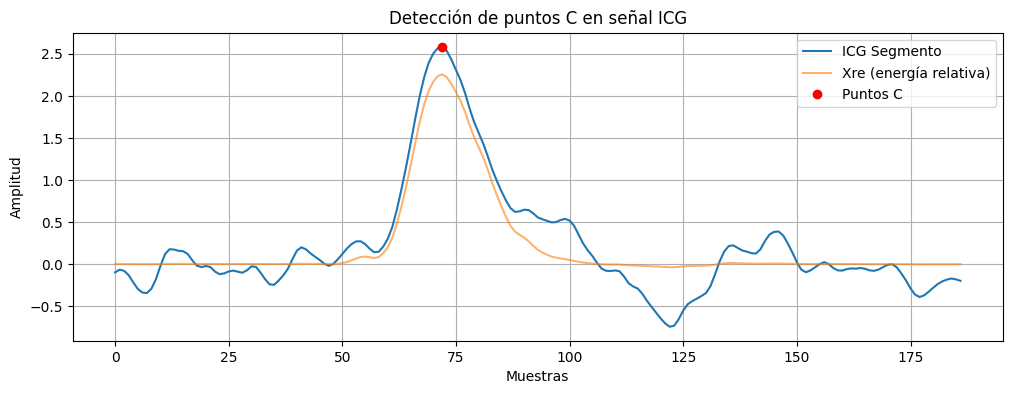

In [43]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

#C-POINT DETECTION

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)

    for n in range(len(signal)):
        i1 = max(0, n - long_len // 2)
        i2 = min(len(signal), n + long_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)

        j1 = max(0, n - short_len // 2)
        j2 = min(len(signal), n + short_len // 2)
        short_energy = np.sum(signal[j1:j2] ** 2)

        if long_energy != 0:
            c = short_energy / long_energy
            Xre[n] = signal[n] * c
    return Xre

def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)

    # Thresholds
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 and sorted_peaks[-2] > np.mean(Xre) else sorted_peaks[-1]

    Thr_max = 0.2 * maxval
    Thr_min = 0.02 * maxval

    C_peaks = []
    active = False
    start_idx = 0

    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active = True
            start_idx = i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if len(C_peaks) == 0 or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    # Filtrar según intervalos C-C
    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            if len(prev_cc) == 5:
                avg_cc = np.mean(prev_cc)
                if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                    final_C_peaks.append(p)
            else:
                final_C_peaks.append(p)

    return np.array(final_C_peaks), Xre


icg_segment = df_segments['Segment'].iloc[2000]  # por ej representamos la cuarta fila
#del dataframe que corresponde con el cuarto fragmento almacenado
fs=250
C_peaks, Xre = detect_C_peaks(icg_segment, fs)

# Representación
plt.figure(figsize=(12, 4))
plt.plot(icg_segment, label="ICG Segmento")
plt.plot(Xre, label="Xre (energía relativa)", alpha=0.6)
plt.plot(C_peaks, icg_segment[C_peaks], 'ro', label="Puntos C")
plt.legend()
plt.title("Detección de puntos C en señal ICG")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


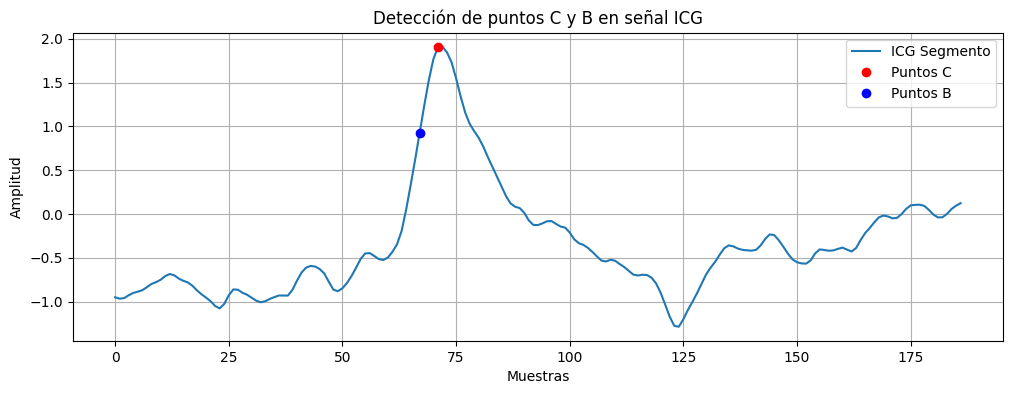

In [12]:
#B-POINT DETECTION
def find_B_point(icg_segment, Cpos, fs, Afrac=0.5, Bslope1=0.11, Bslope2=0.08):
    # Paso 1: calcular límites de la ventana de búsqueda
    BlimL = max(0, int(Cpos - 0.08 * fs))  # 80 ms antes del C
    C_amp = icg_segment[Cpos]

    # Buscar BlimR: el índice más cercano a la izquierda donde la señal < Afrac * C_amp
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * C_amp:
            BlimR = i
            break
    else:
        BlimR = BlimL  # Si no se encuentra, que sea igual al límite inferior

    # Derivada primera (pendiente) de la señal
    slope = np.gradient(icg_segment)

    # Paso 2: búsqueda con Bslope1
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and (icg_segment[i] < icg_segment[i-1])) or abs(slope[i]) > Bslope1:
            return i

    # Paso 3: búsqueda con Bslope2
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i

    # Paso 4: si no se encuentra, retornar el mínimo de la ventana
    search_region = icg_segment[BlimL:BlimR+1]
    return BlimL + np.argmin(search_region)

B_points = []
for Cpos in C_peaks:
    B_idx = find_B_point(icg_segment, Cpos, fs)
    B_points.append(B_idx)

# Visualización
plt.figure(figsize=(12, 4))
plt.plot(icg_segment, label="ICG Segmento")
plt.plot(C_peaks, icg_segment[C_peaks], 'ro', label="Puntos C")
plt.plot(B_points, icg_segment[B_points], 'bo', label="Puntos B")
plt.legend()
plt.title("Detección de puntos C y B en señal ICG")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


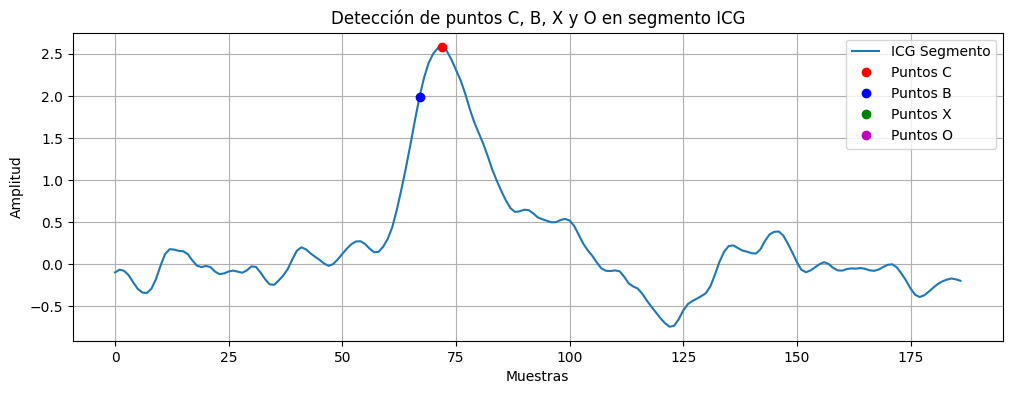

In [44]:
from scipy.signal import argrelextrema
import numpy as np

def find_XO_points(icg_segment, Cpos, fs, debug=False):
    # Parámetros en muestras
    COmin = int(0.020 * fs)
    COmax = int(0.040 * fs)
    CXmin = int(0.015 * fs)
    CXmax = int(0.030 * fs)

    # Buscar candidatos O: máximos locales entre [C + COmin, C + COmax]
    O_win_start = Cpos + COmin
    O_win_end = Cpos + COmax
    if O_win_end > len(icg_segment): return (None, None)

    O_window = icg_segment[O_win_start:O_win_end]
    O_candidates = O_win_start + argrelextrema(O_window, np.greater)[0]

    # Buscar candidatos X: mínimos locales entre [C + CXmin, C + CXmax]
    X_win_start = Cpos + CXmin
    X_win_end = Cpos + CXmax
    if X_win_end > len(icg_segment): return (None, None)

    X_window = icg_segment[X_win_start:X_win_end]
    X_candidates = X_win_start + argrelextrema(X_window, np.less)[0]

    if debug:
        print(f"Cpos: {Cpos}, O_candidates: {O_candidates}, X_candidates: {X_candidates}")

    # Buscar pares válidos
    best_pair = (None, None)
    max_amp_diff = -np.inf

    for X in X_candidates:
        for O in O_candidates:
            if O > X:
                delta_t = (O - X) / fs  # tiempo en segundos
                if 0.002 <= delta_t <= 0.015:  # entre 2 y 15 ms
                    segment_between = icg_segment[X:O]
                    num_minima = len(argrelextrema(segment_between, np.less)[0])
                    if num_minima < 3:
                        amp_diff = icg_segment[O] - icg_segment[X]
                        if amp_diff > max_amp_diff:
                            max_amp_diff = amp_diff
                            best_pair = (X, O)

    return best_pair
X_points = []
O_points = []

for Cpos in C_peaks:
    X, O = find_XO_points(icg_segment, Cpos, fs)
    X_points.append(X)
    O_points.append(O)

#Plot completo
plt.figure(figsize=(12, 4))
plt.plot(icg_segment, label="ICG Segmento")
plt.plot(C_peaks, icg_segment[C_peaks], 'ro', label="Puntos C")
plt.plot(B_points, icg_segment[B_points], 'bo', label="Puntos B")
plt.plot(X_points, [icg_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
plt.plot(O_points, [icg_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
plt.legend()
plt.title("Detección de puntos C, B, X y O en segmento ICG")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


Respecto al algoritmo de detección de puntos O y X de ReBeat, lo he intentado de múltiples modos y no obtengo resultados concluyentes. No sé si es por el algoritmo o porque realmente tampoco se encuentran esos puntos en la señal. Esta última opción también es posible ya que hay distintos subcomplejos que sabemos que precisamente difieren de la señal ideal por el hecho de no presentar todos los puntos característicos. Es por ello que creo que debería investigar otros algoritmos de detección de puntos X y O para saber en cuál de las dos opciones me encuentro.

###Ahora vamos a aplicar algoritmos de aprendizaje no supervisado de clustering.

In [18]:
import numpy as np

#Todos los segmentos deben tener la misma longitud
segment_lengths = df_segments['Segment'].apply(len)
print(segment_lengths.unique())

X = np.stack(df_segments['Segment'].values)
print(X.shape)  # Debe ser (n_segmentos, longitud_segmento)


[187]
(16912, 187)


###**K-MEANS**:

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)
df_segments['Cluster'] = labels #creamos una nueva columna que contiene el resultado del clustering


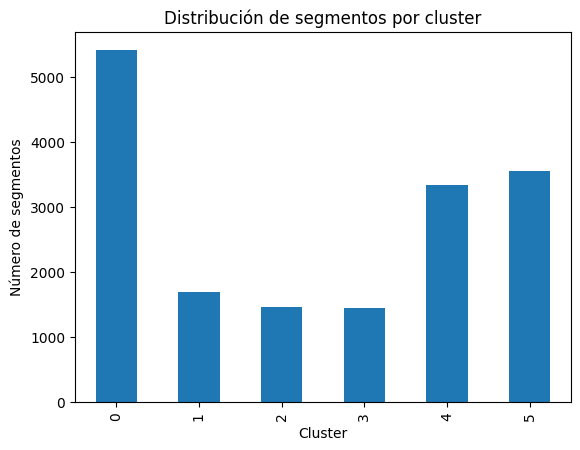

In [7]:
import matplotlib.pyplot as plt
#Para visualizar el número de segmentos que hay en cada cluster:
df_segments['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Número de segmentos")
plt.title("Distribución de segmentos por cluster")
plt.show()

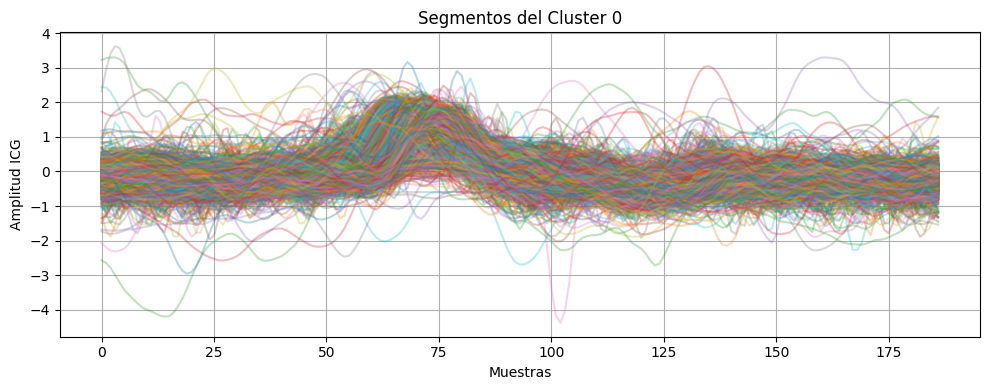

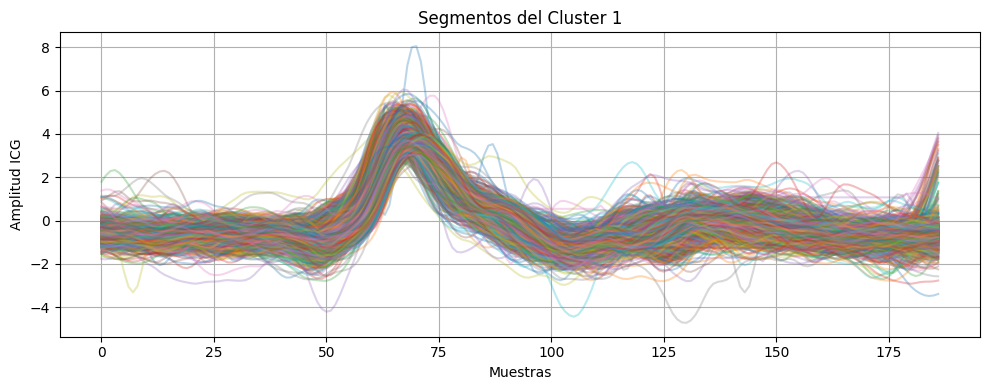

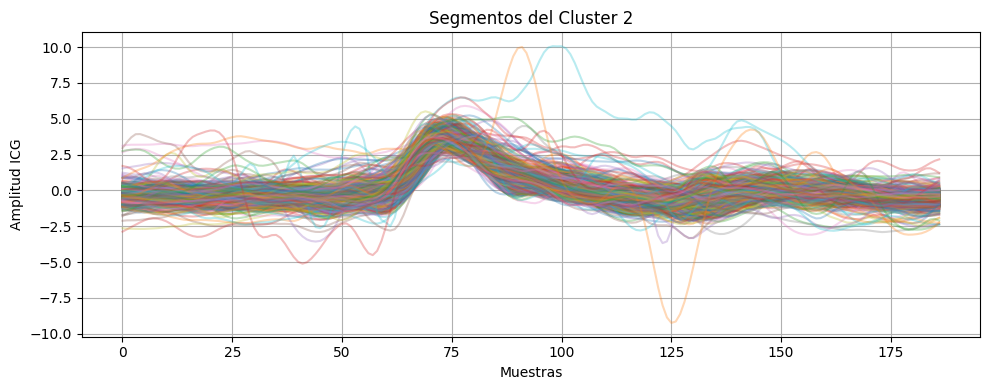

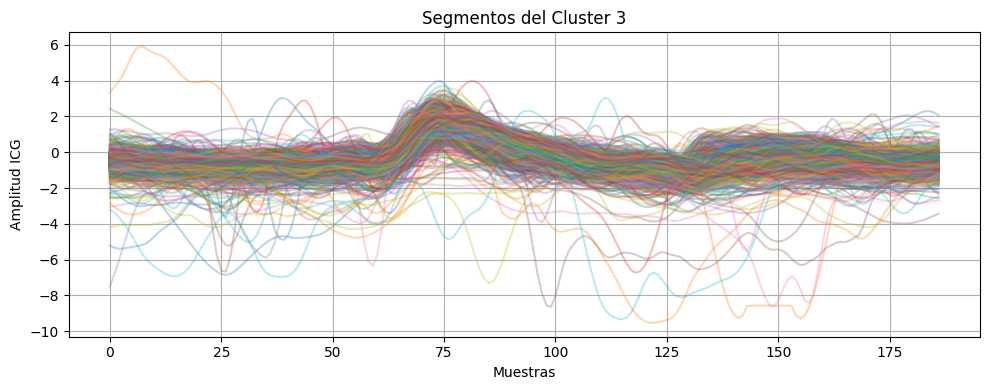

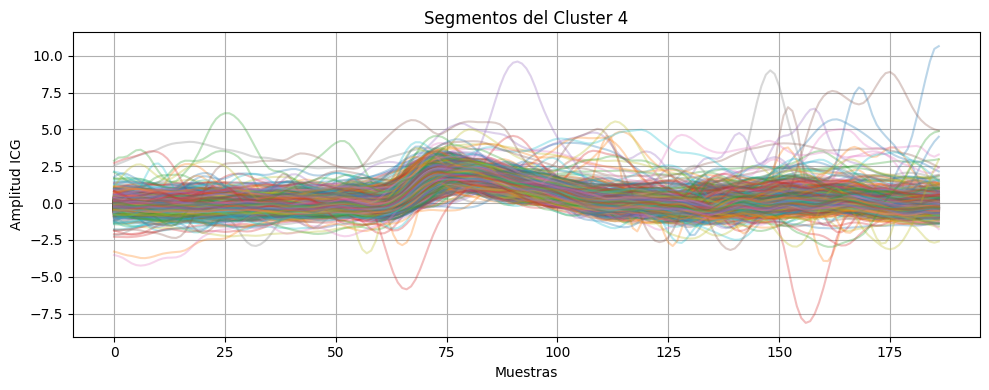

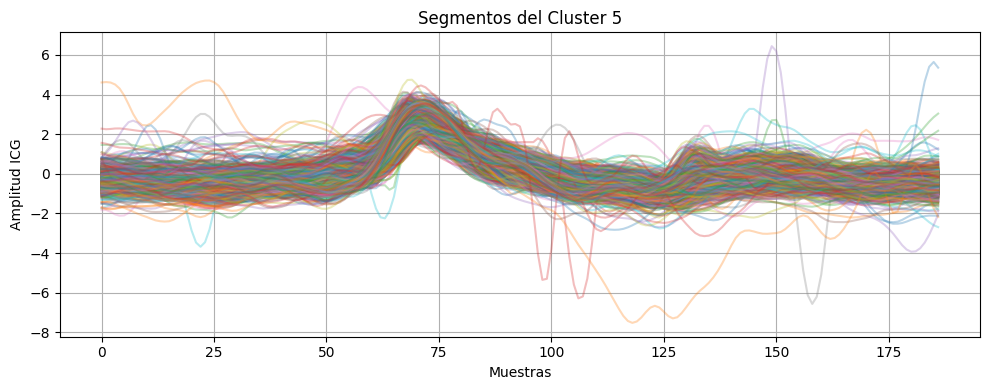

In [20]:
#Para visulaizar la respresentación de segmentos en cada cluster
# Número de clusters
n_clusters = 6

# Crear una figura por cada cluster
for cluster_id in range(n_clusters):
    # Filtrar los segmentos del cluster actual
    cluster_data = df_segments[df_segments['Cluster'] == cluster_id]['Segment']

    plt.figure(figsize=(10, 4))
    for segment in cluster_data:
        plt.plot(segment, alpha=0.3)  # alpha para hacer las curvas más transparentes


    plt.title(f"Segmentos del Cluster {cluster_id}")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud ICG")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


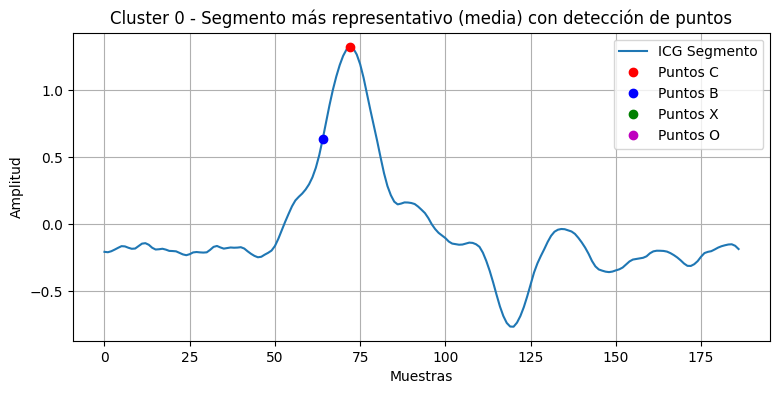

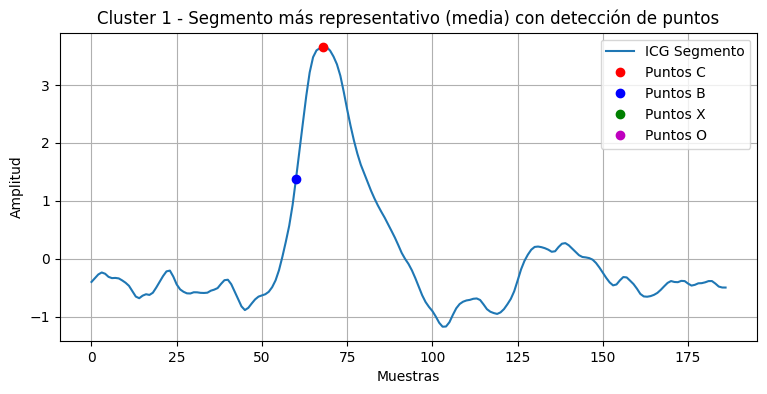

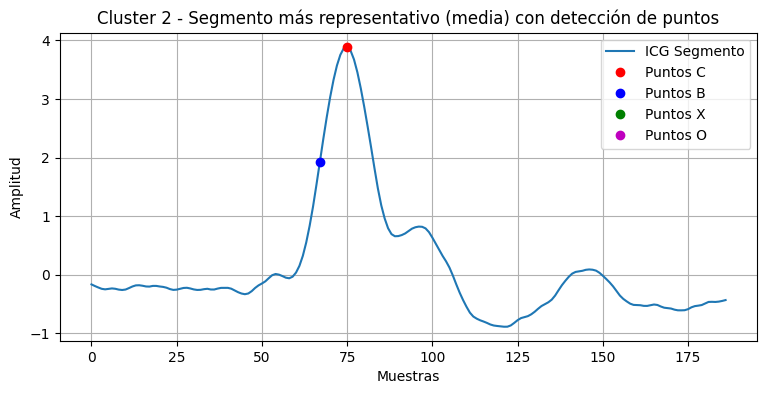

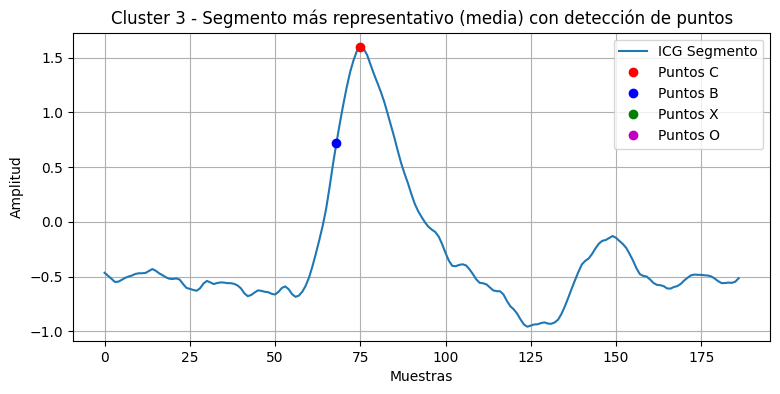

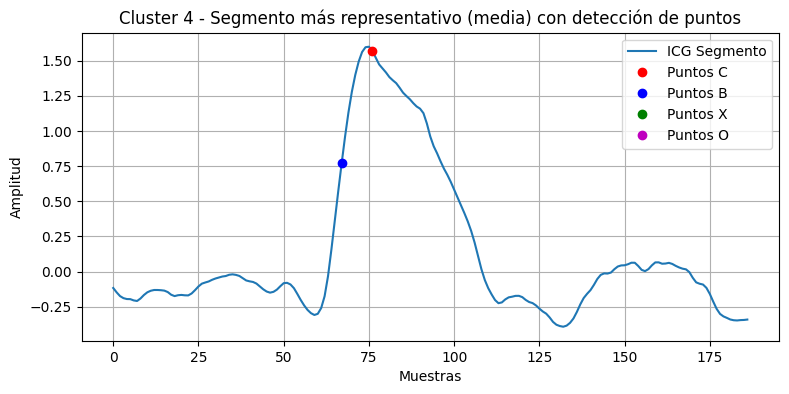

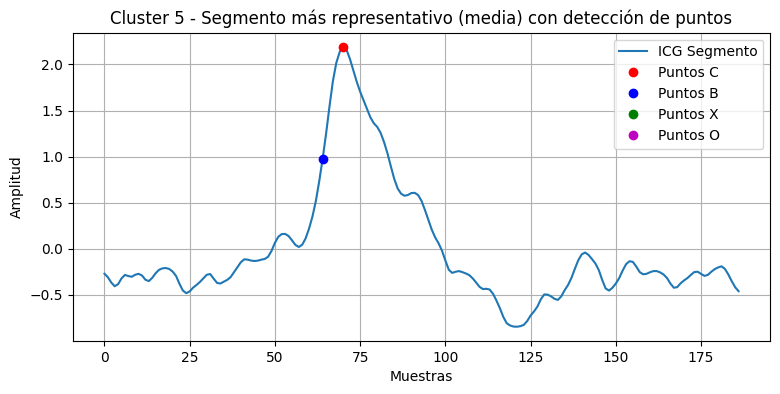

In [23]:
#Para visualizar el segmento más representativo de cada tipo de cluster. Basado en la MEDIA.
from scipy.spatial.distance import cdist

for cluster_id in range(n_clusters):
    cluster_data = df_segments[df_segments['Cluster'] == cluster_id]['Segment']
    segment_matrix = np.stack(cluster_data.values)

    # Calcular la media
    mean_segment = np.mean(segment_matrix, axis=0)

    # Calcular la distancia de cada segmento al promedio
    distances = cdist(segment_matrix, [mean_segment], metric='euclidean')

    # Encontrar el índice del segmento más cercano a la media
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

    # Graficar solo el más representativo
    #plt.figure(figsize=(6, 3))
    #plt.plot(representative_segment, color='blue', linewidth=1.5)

    #plt.title(f"Cluster {cluster_id} - Segmento más representativo (media)")
    #plt.xlabel("Muestras")
    #plt.ylabel("Amplitud ICG")
    #plt.grid(True)
    #plt.tight_layout()
    #plt.show()

    #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (media) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()


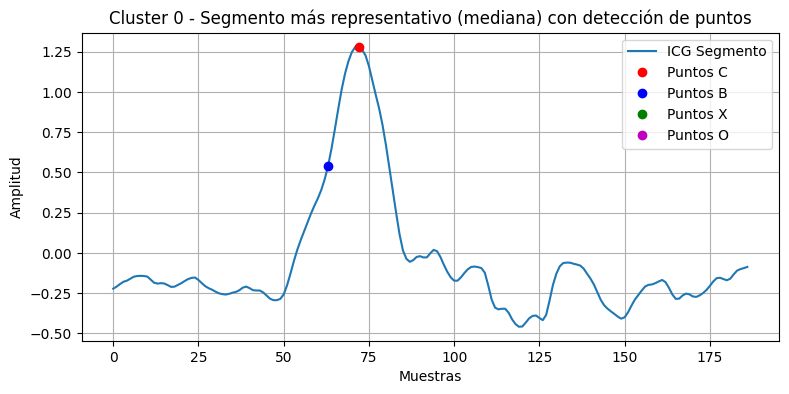

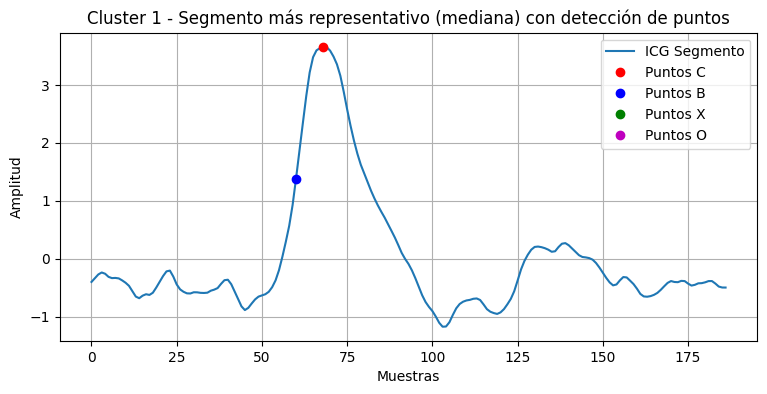

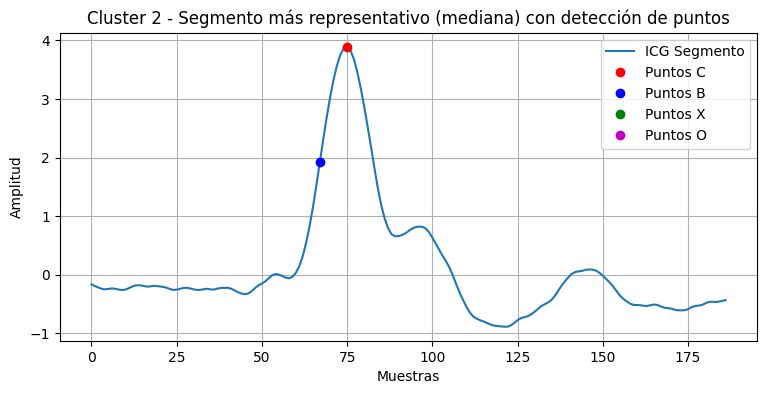

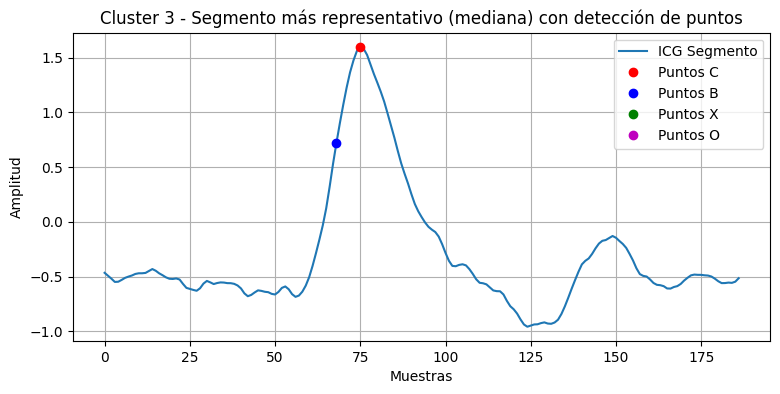

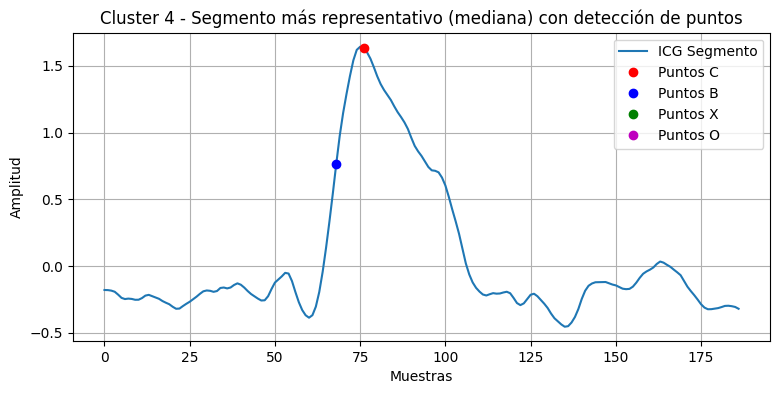

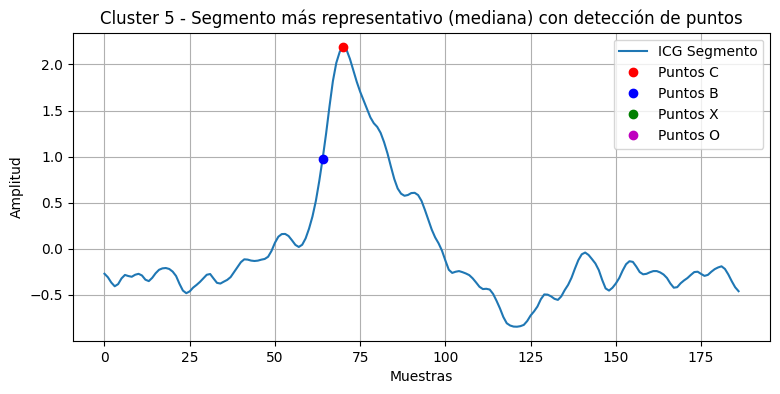

In [28]:
#Para visualizar el segmento más representativo de cada tipo de cluster. Basado en la MEDIANA.
for cluster_id in range(n_clusters):
    cluster_data = df_segments[df_segments['Cluster'] == cluster_id]['Segment']
    segment_matrix = np.stack(cluster_data.values)

    # Calcular la mediana punto a punto
    median_segment = np.median(segment_matrix, axis=0)

    # Calcular la distancia de cada segmento a la mediana
    distances = cdist(segment_matrix, [median_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

       #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (mediana) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

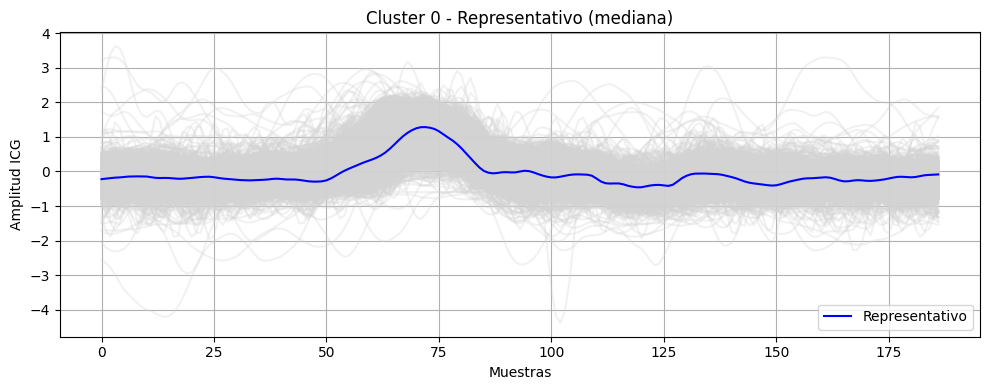

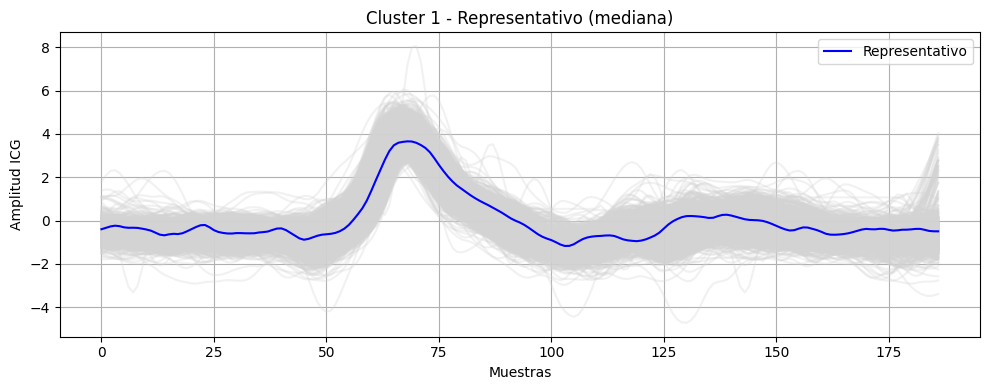

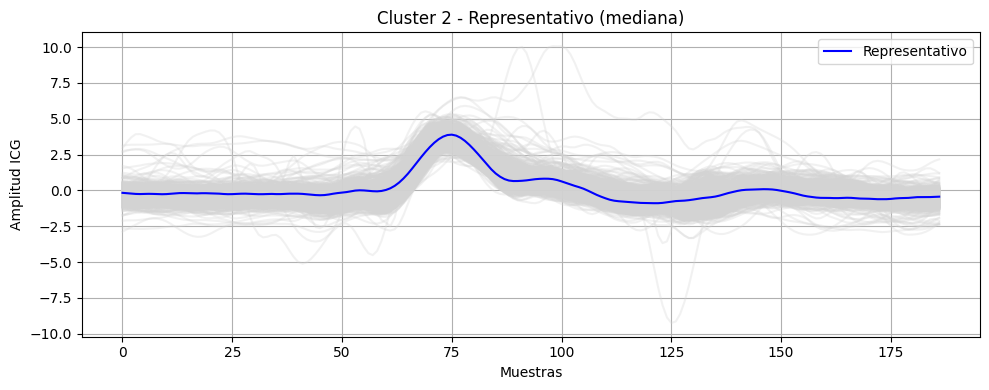

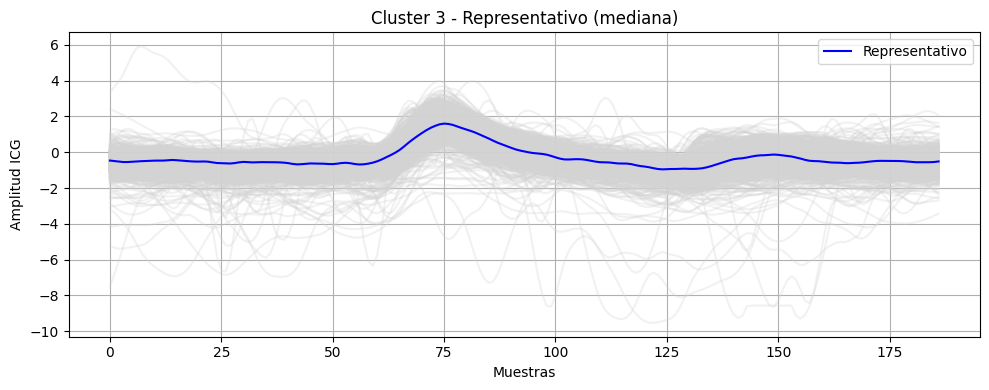

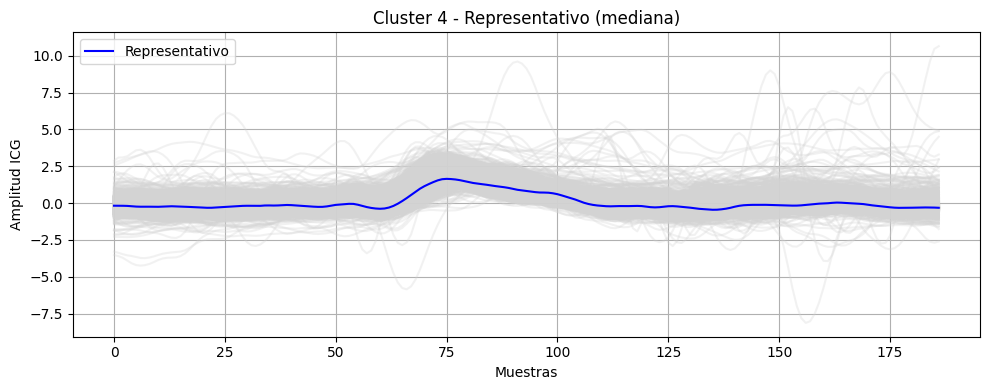

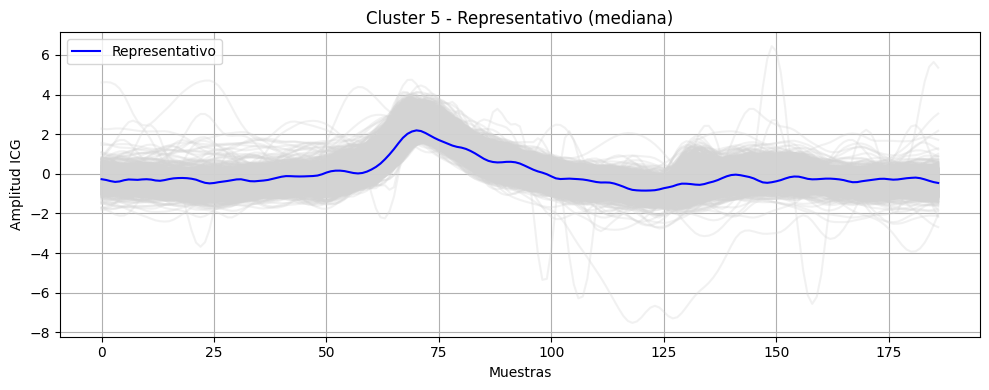

In [25]:
#Representación de todas los segmentos por cluster y segmento más representativo de cada cluster basado en la MEDIANA.
for cluster_id in range(n_clusters):
    cluster_data = df_segments[df_segments['Cluster'] == cluster_id]['Segment']
    segment_matrix = np.stack(cluster_data.values)

    # Calcular la mediana punto a punto
    median_segment = np.median(segment_matrix, axis=0)

    # Calcular la distancia de cada segmento a la mediana
    distances = cdist(segment_matrix, [median_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

    # Plot para comparación
    plt.figure(figsize=(10, 4))
    for segment in segment_matrix:
        plt.plot(segment, color='lightgray', alpha=0.3)

    plt.plot(representative_segment, color='blue', linewidth=1.5, label='Representativo')

    plt.title(f"Cluster {cluster_id} - Representativo (mediana)")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud ICG")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Conclusiones: obtenemos 6 subcomplejos donde algunos sí se parecen mucho a algunos del paper y otros no tienen mucha similitud. Continuaremos probando con otros algoritmos.

###**HDBSCAN:**

In [27]:
!pip install hdbscan


In [29]:
import hdbscan
from sklearn.preprocessing import StandardScaler

# Extraer solo las señales para clustering
X = np.stack(df_segments['Segment'].values)

# Escalar cada segmento para que el clustering no se vea afectado por amplitudes distintas
X_scaled = StandardScaler().fit_transform(X)

# Aplicar HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=50, metric='euclidean')
#min_cluster_size=200: Cada grupo debe tener al menos 200 segmentos.
#min_samples=50: Un punto necesita tener al menos 50 vecinos cercanos para no considerarse ruido.
#Estas restricciones se han añadido para disminuir el número de clusters obtenidos y disminuir el número de segmentos marcados como ruido.
labels = clusterer.fit_predict(X_scaled)

# Guardar etiquetas en el DataFrame
df_segments['Cluster_HDBSCAN'] = labels

# Ver resultados
print(f"Número de clusters encontrados (sin contar ruido): {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Número de segmentos marcados como ruido: {(labels == -1).sum()}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Número de clusters encontrados (sin contar ruido): 6
Número de segmentos marcados como ruido: 10816


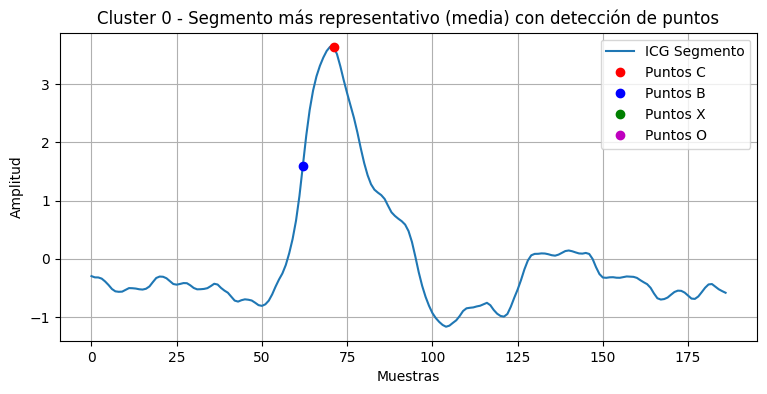

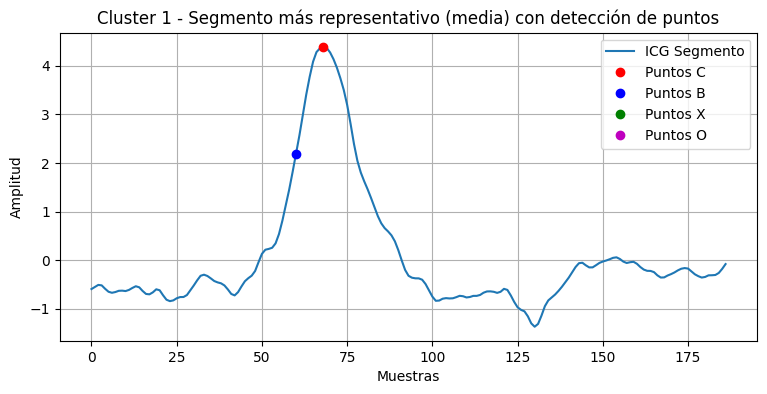

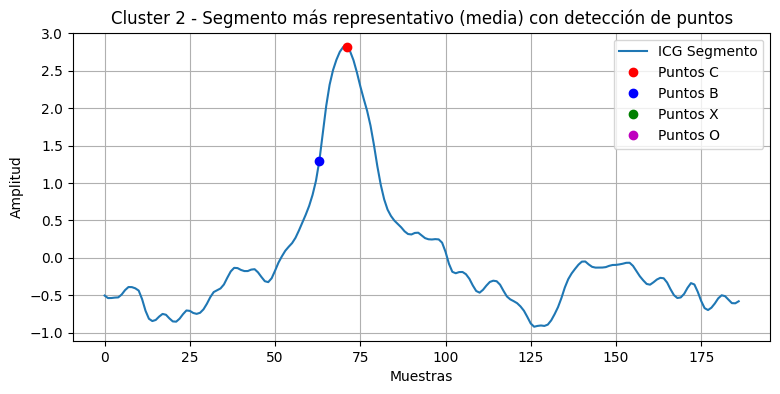

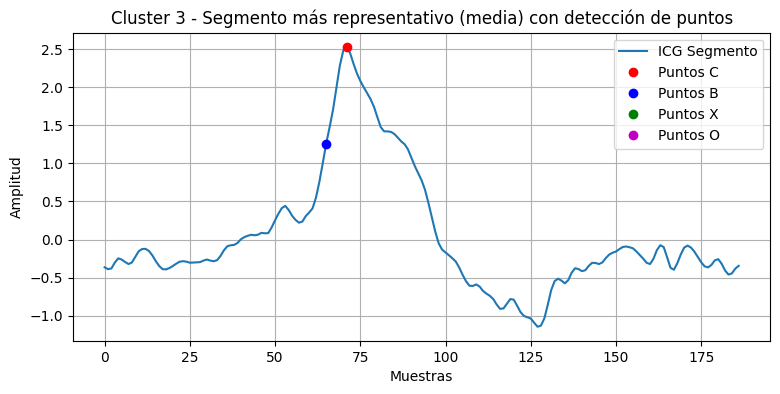

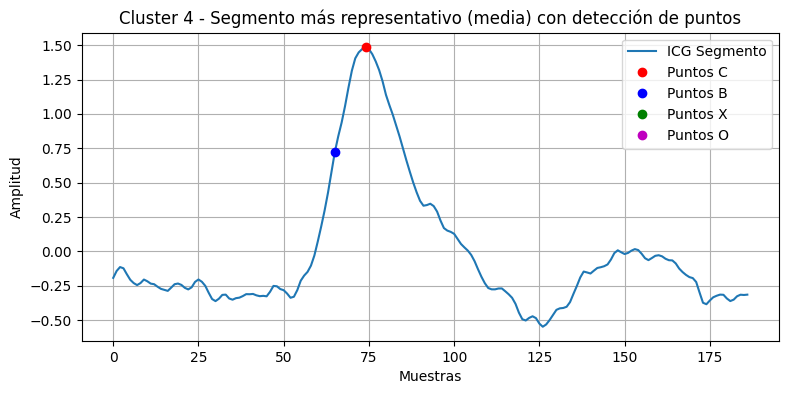

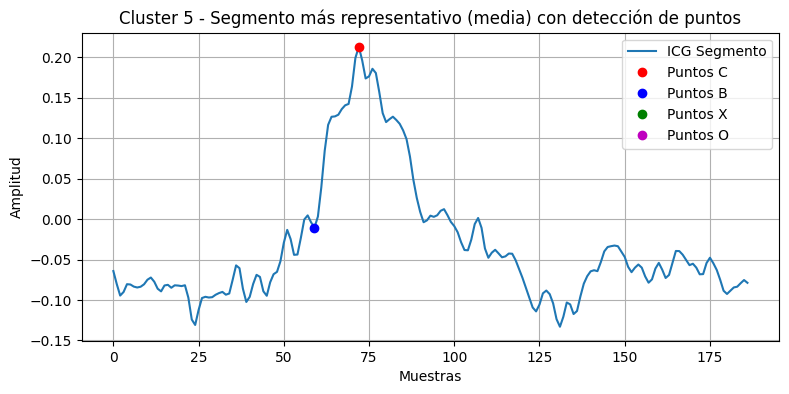

In [30]:
#A continuación visualizaremos la señal representativa de cada cluster obtenido basado en la MEDIA.
from scipy.spatial.distance import cdist

for cluster_id in sorted(df_segments['Cluster_HDBSCAN'].unique()):
    if cluster_id == -1:
        continue  # Ignorar el ruido

    cluster_data = df_segments[df_segments['Cluster_HDBSCAN'] == cluster_id]
    segments = np.stack(cluster_data['Segment'].values)

    # Calcular la media
    mean_segment = np.mean(segments, axis=0)
    distances = cdist(segments, [mean_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segments[closest_idx]

    #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (media) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

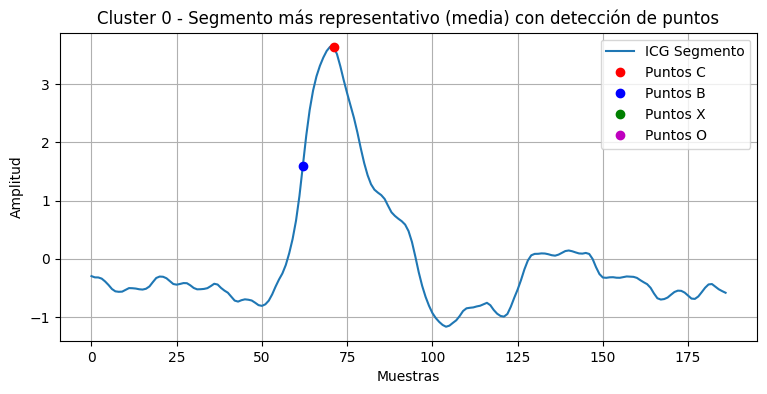

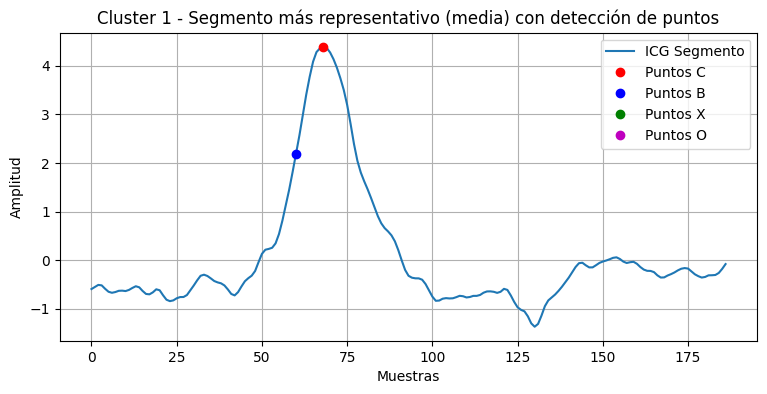

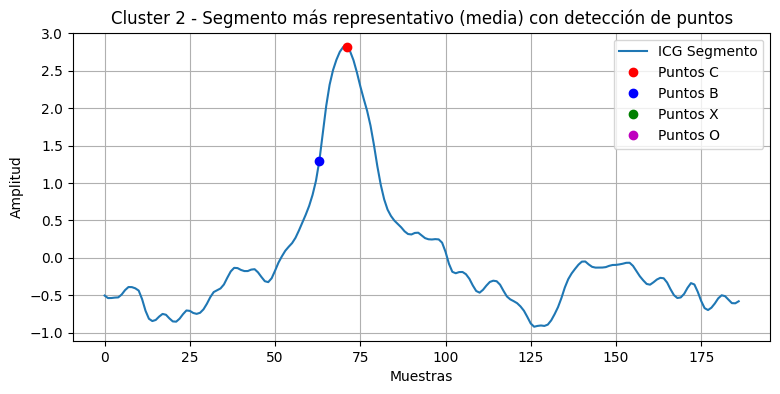

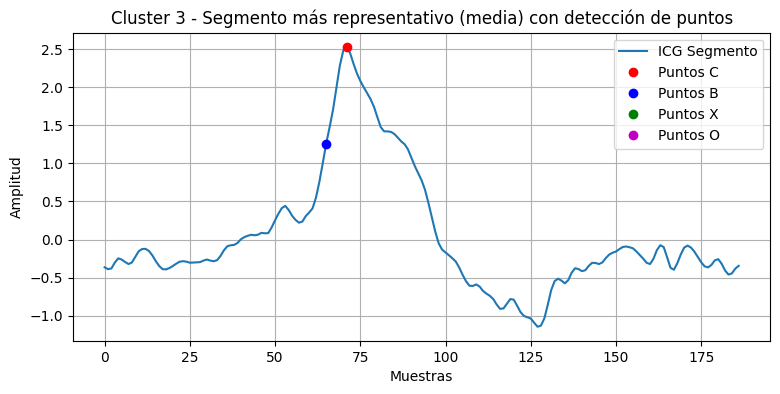

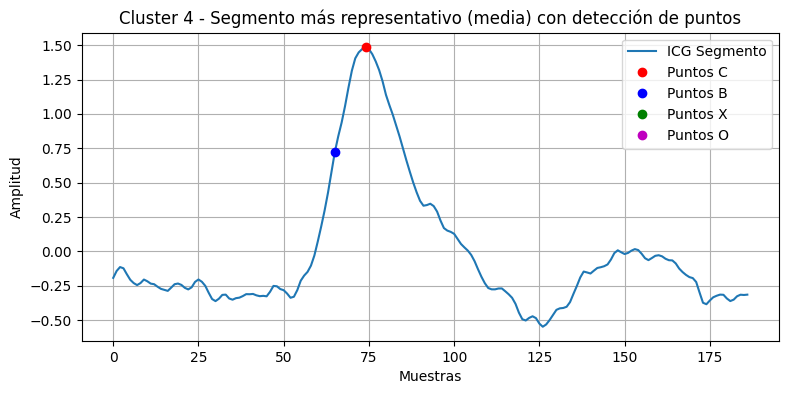

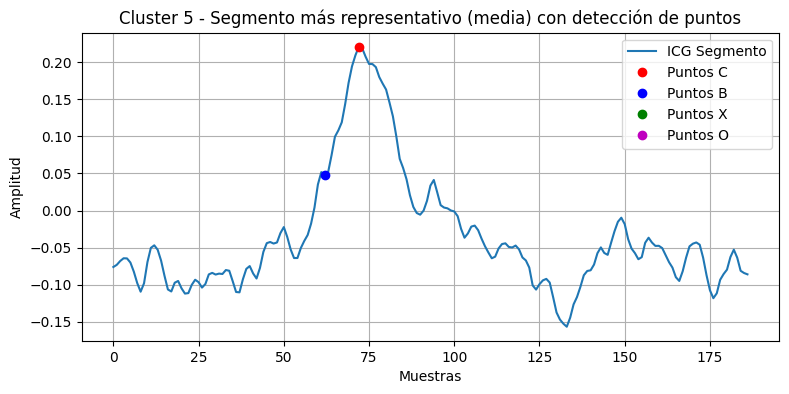

In [31]:
#A continuación visualizaremos la señal representativa de cada cluster obtenido basado en la MEDIANA.
from scipy.spatial.distance import cdist

for cluster_id in sorted(df_segments['Cluster_HDBSCAN'].unique()):
    if cluster_id == -1:
        continue  # Ignorar el ruido

    cluster_data = df_segments[df_segments['Cluster_HDBSCAN'] == cluster_id]
    segments = np.stack(cluster_data['Segment'].values)

    # Calcular la mediana
    median_segment = np.median(segments, axis=0)
    distances = cdist(segments, [median_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segments[closest_idx]

    #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (mediana) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

Cluster 0 - Varianza media entre señales: 0.05


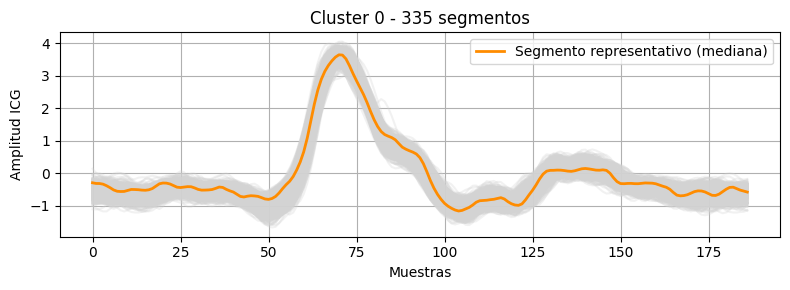

Cluster 1 - Varianza media entre señales: 0.04


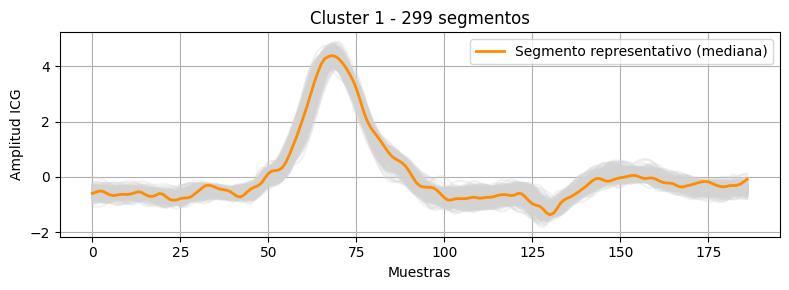

Cluster 2 - Varianza media entre señales: 0.02


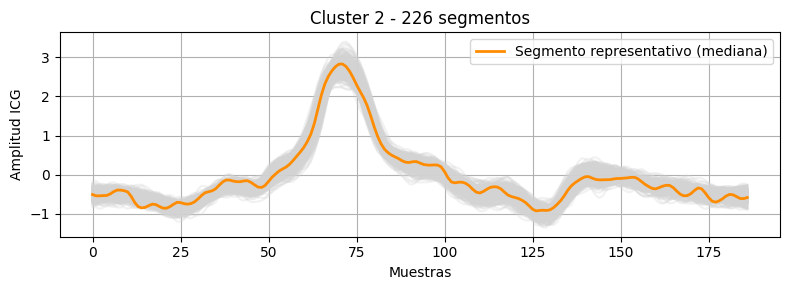

Cluster 3 - Varianza media entre señales: 0.03


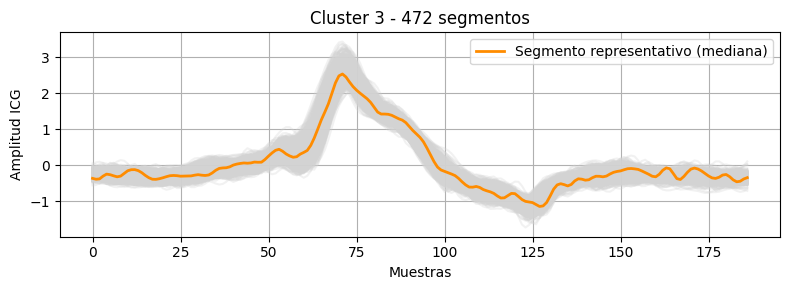

Cluster 4 - Varianza media entre señales: 0.07


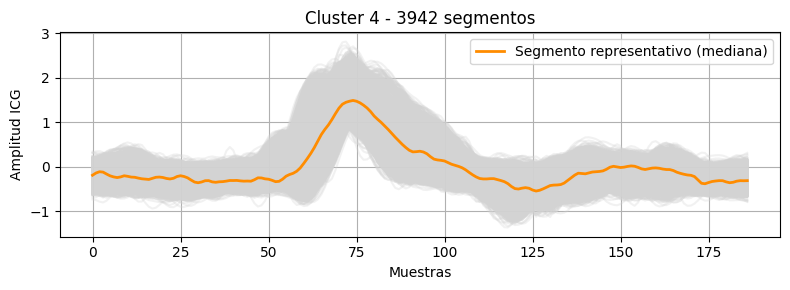

Cluster 5 - Varianza media entre señales: 0.00


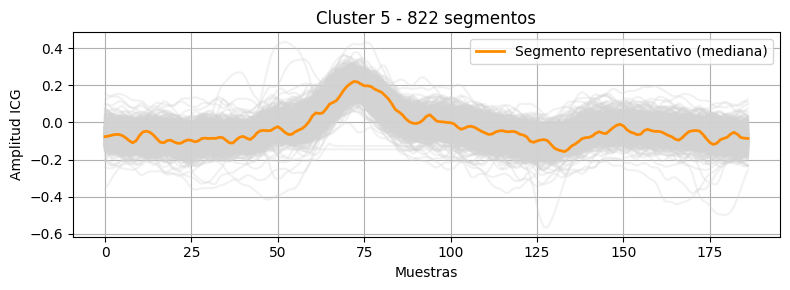

In [ ]:
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Obtener los clusters únicos generados por HDBSCAN (excepto el -1, que es ruido)
unique_clusters = sorted(df_segments['Cluster_HDBSCAN'].unique())
unique_clusters = [c for c in unique_clusters if c != -1]

for cluster_id in unique_clusters:
    cluster_data = df_segments[df_segments['Cluster_HDBSCAN'] == cluster_id]['Segment']

    if len(cluster_data) == 0:
        continue  # Evitar errores si el cluster está vacío

    segment_matrix = np.stack(cluster_data.values)

    # Calcular la mediana punto a punto
    median_segment = np.median(segment_matrix, axis=0)

    # Calcular la distancia de cada segmento a la mediana
    distances = cdist(segment_matrix, [median_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

    # Plot
    plt.figure(figsize=(8, 3))
    for segment in segment_matrix:
        plt.plot(segment, color='lightgray', alpha=0.3)

    #Calcular la varianza entre las señales de un mismo cluster
    variance = np.var(segment_matrix, axis=0)
    mean_variance = np.mean(variance)
    print(f"Cluster {cluster_id} - Varianza media entre señales: {mean_variance:.2f}")

    plt.plot(representative_segment, color='darkorange', linewidth=2, label='Segmento representativo (mediana)')

    plt.title(f"Cluster {cluster_id} - {len(segment_matrix)} segmentos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud ICG")
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()


Este algortimo la primera vez que lo he ejecutado me proporcionaba 18 clusters y 10291 segmentos marcados como ruido. Sin embargo, al añadir las 2 restricciones marcadas en el código, he obtenido directamente 6 clusters y menos segmentos marcados con ruido, lo cual cobra bastante sentido. No obstante, a continuación analizaremos algún otro método.


###**Spectral clustering**:

In [32]:
from sklearn.cluster import SpectralClustering
import numpy as np

# Convertimos la columna 'Segment' a una matriz para clustering
X = np.stack(df_segments['Segment'].values)

# Número de clusters deseado
n_clusters = 6

# Aplicamos el clustering espectral
spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
labels = spectral.fit_predict(X)
#Aquí podría ajustar algunos parámetros: affinity='nearest_neighbors', assign_labels='kmeans'

# Añadimos los resultados al DataFrame
df_segments['Cluster_Spectral'] = labels


Cluster 0 - Varianza media entre señales: 0.20


<ipython-input-73-d94b173840b2>:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


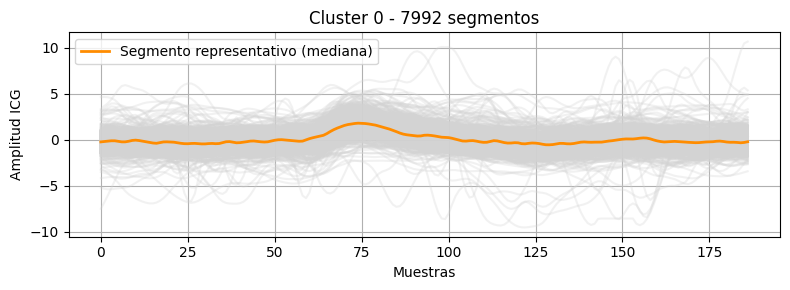

Cluster 1 - Varianza media entre señales: 0.01


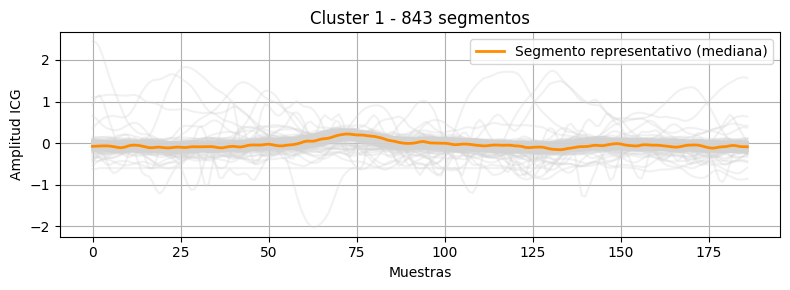

Cluster 2 - Varianza media entre señales: 0.22


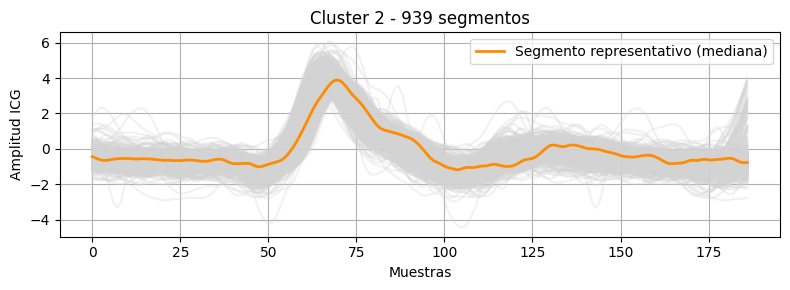

Cluster 3 - Varianza media entre señales: 0.08


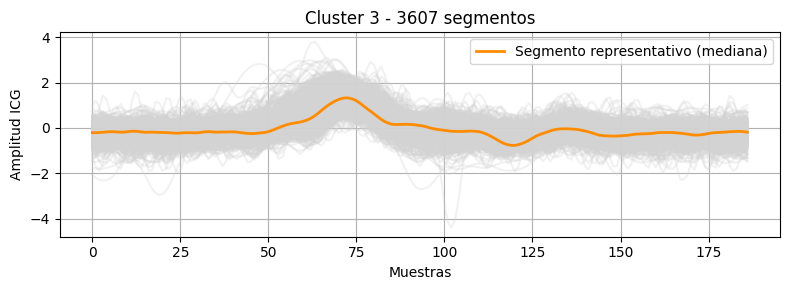

Cluster 4 - Varianza media entre señales: 0.11


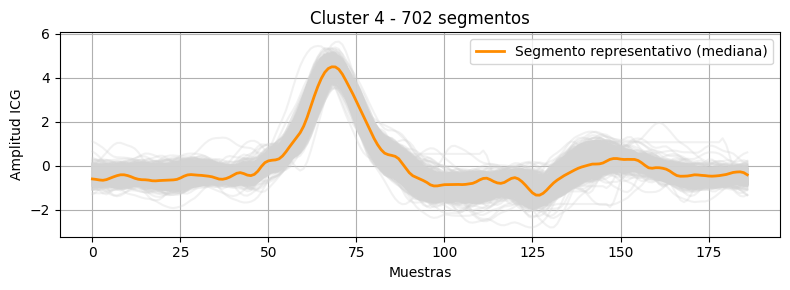

Cluster 5 - Varianza media entre señales: 0.24


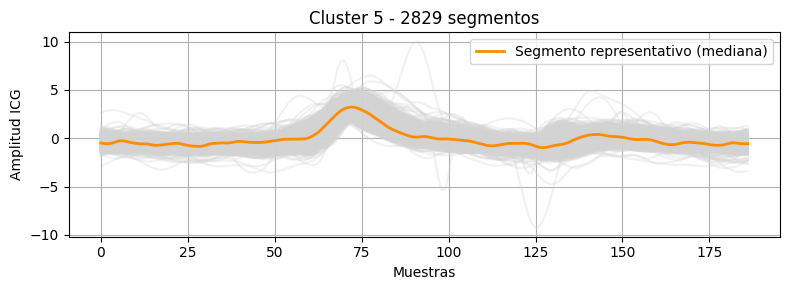

In [ ]:
# Visualización por cluster con segmento representativo (mediana)
unique_clusters = sorted(df_segments['Cluster_Spectral'].unique())

for cluster_id in unique_clusters:
    cluster_data = df_segments[df_segments['Cluster_Spectral'] == cluster_id]['Segment']

    if len(cluster_data) == 0:
        continue

    segment_matrix = np.stack(cluster_data.values)
    median_segment = np.median(segment_matrix, axis=0)
    distances = cdist(segment_matrix, [median_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]


    plt.figure(figsize=(8, 3))
    for segment in segment_matrix:
        plt.plot(segment, color='lightgray', alpha=0.3)

    #Calcular la varianza entre las señales de un mismo cluster
    variance = np.var(segment_matrix, axis=0)
    mean_variance = np.mean(variance)
    print(f"Cluster {cluster_id} - Varianza media entre señales: {mean_variance:.2f}")

    plt.plot(representative_segment, color='darkorange', linewidth=2, label='Segmento representativo (mediana)')
    plt.title(f"Cluster {cluster_id} - {len(segment_matrix)} segmentos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud ICG")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


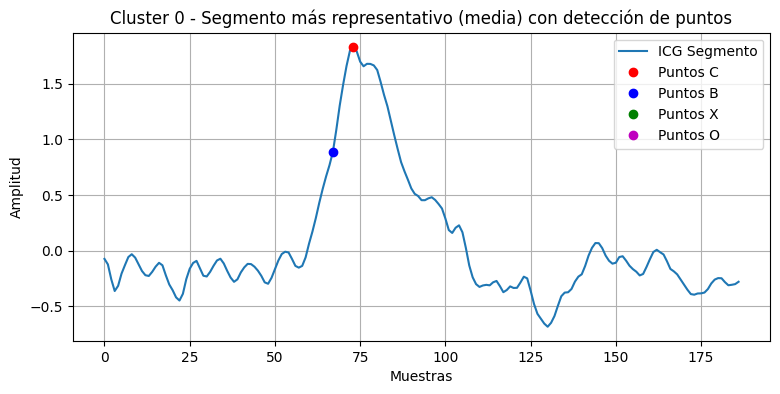

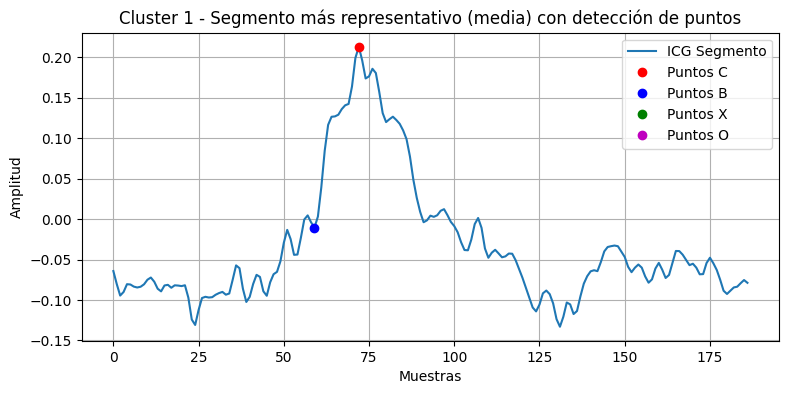

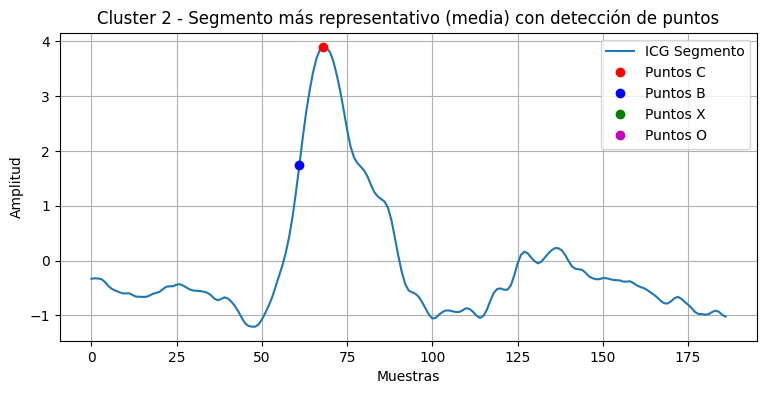

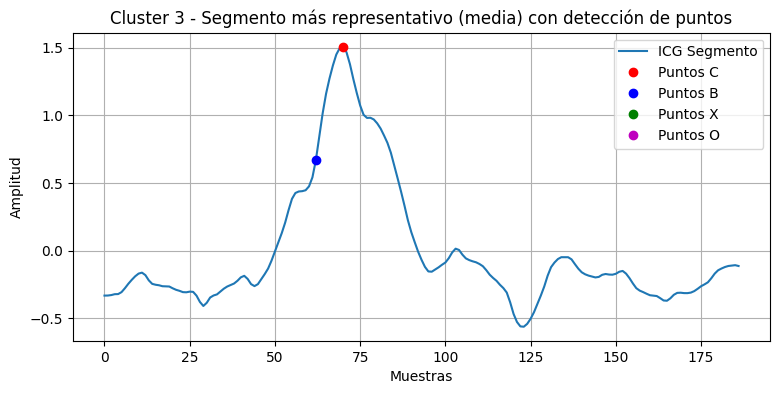

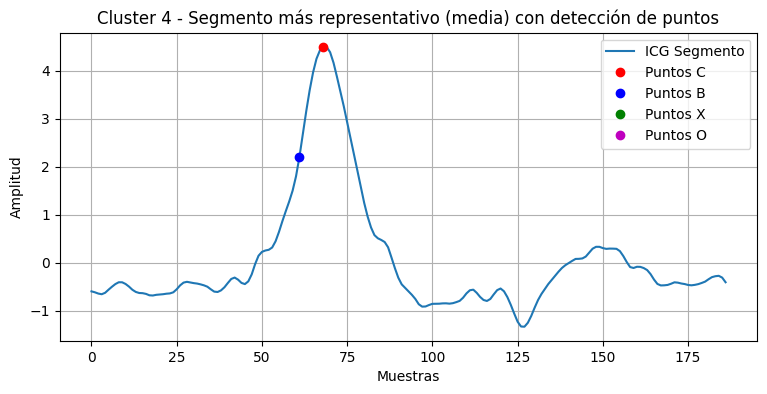

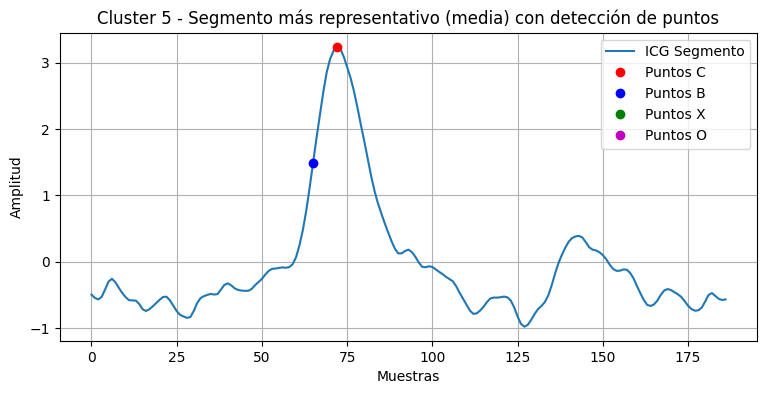

In [34]:
#Plots de segmento más representativo del cluster basado en la MEDIA
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Lista de clusters únicos (ordenados por número para claridad)
unique_clusters = sorted(df_segments['Cluster_Spectral'].unique())

for cluster_id in unique_clusters:
    cluster_data = df_segments[df_segments['Cluster_Spectral'] == cluster_id]['Segment']

    if len(cluster_data) == 0:
        continue

    # Convertimos a matriz para cálculo
    segment_matrix = np.stack(cluster_data.values)

    # Media punto a punto
    mean_segment = np.mean(segment_matrix, axis=0)

    # Elegimos el segmento más cercano a la mediana
    distances = cdist(segment_matrix, [mean_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

     #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (media) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

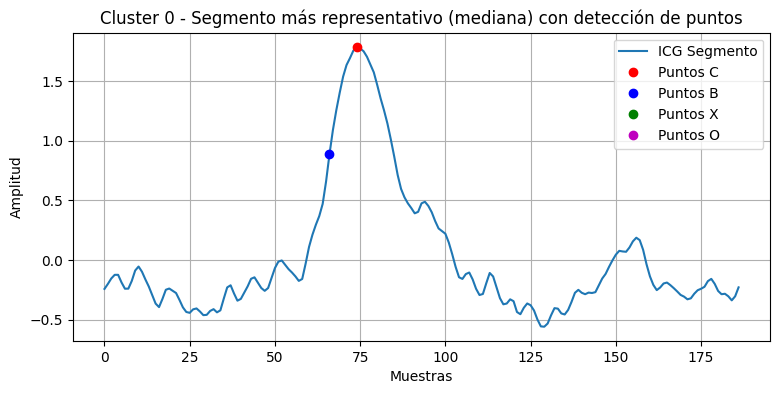

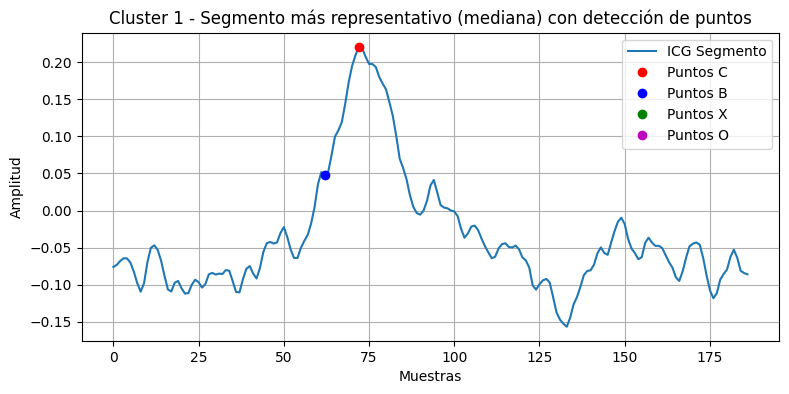

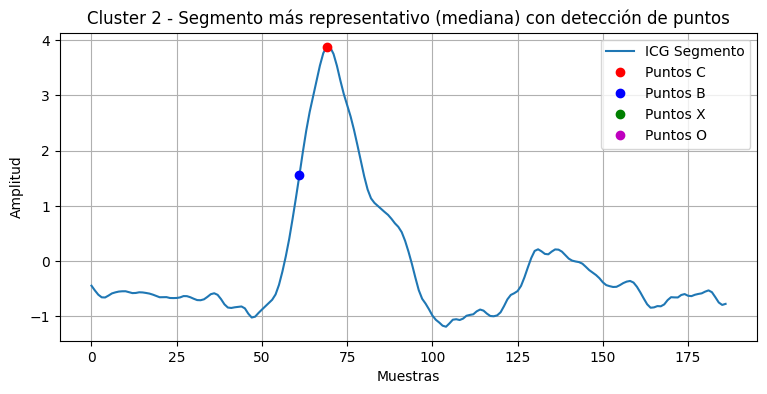

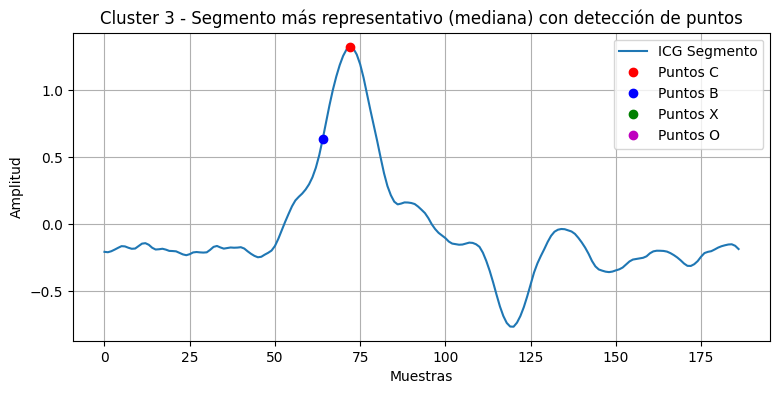

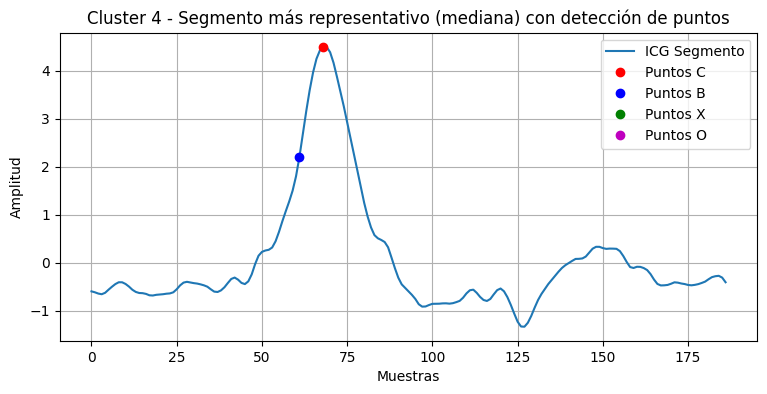

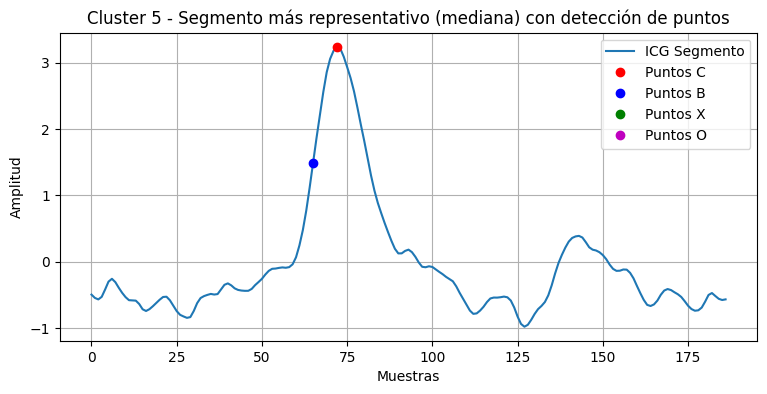

In [33]:
#Plots de segmento más representativo del cluster basado en la MEDIANA
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Lista de clusters únicos (ordenados por número para claridad)
unique_clusters = sorted(df_segments['Cluster_Spectral'].unique())

for cluster_id in unique_clusters:
    cluster_data = df_segments[df_segments['Cluster_Spectral'] == cluster_id]['Segment']

    if len(cluster_data) == 0:
        continue

    # Convertimos a matriz para cálculo
    segment_matrix = np.stack(cluster_data.values)

    # Mediana punto a punto
    median_segment = np.median(segment_matrix, axis=0)

    # Elegimos el segmento más cercano a la mediana
    distances = cdist(segment_matrix, [median_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

     #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (mediana) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()


###**Hierarchical Clustering (Agglomerative):**

In [35]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Convertimos los segmentos en una matriz (cada fila = un segmento)
segment_matrix = np.stack(df_segments['Segment'].values)

# Clustering jerárquico
n_clusters = 6
agglo = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')

labels = agglo.fit_predict(segment_matrix)

# Guardamos los clusters en el DataFrame
df_segments['Cluster'] = labels


Cluster 0 - Varianza media entre señales: 0.09


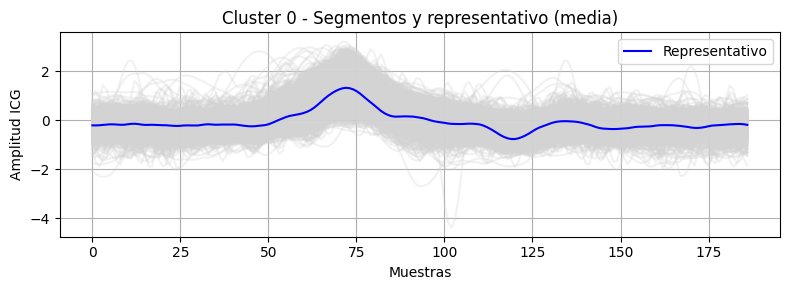

Cluster 1 - Varianza media entre señales: 0.17


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


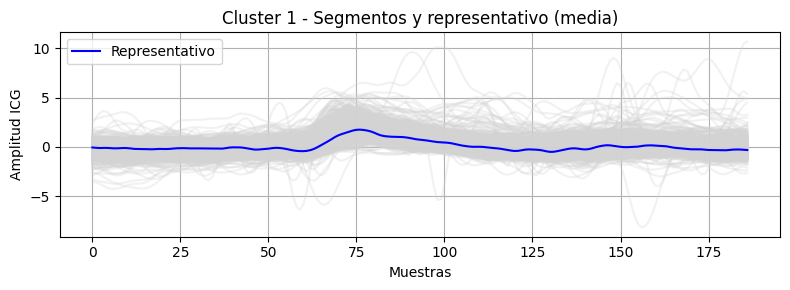

Cluster 2 - Varianza media entre señales: 0.23


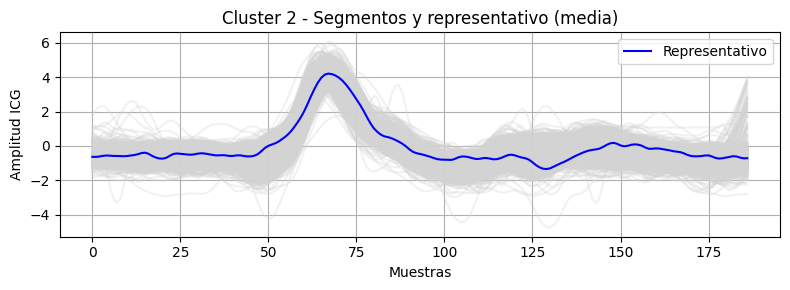

Cluster 3 - Varianza media entre señales: 0.19


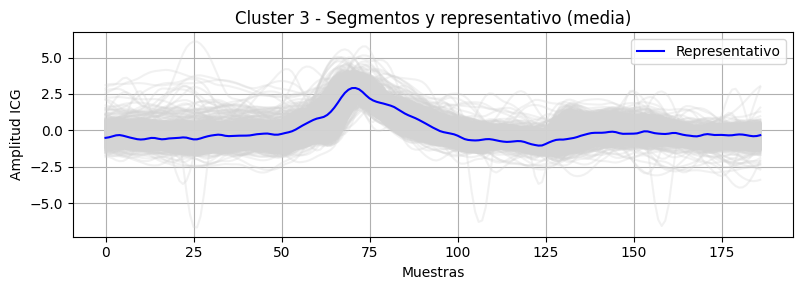

Cluster 4 - Varianza media entre señales: 0.44


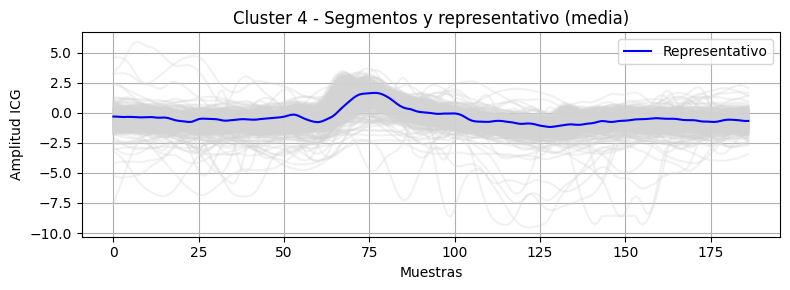

Cluster 5 - Varianza media entre señales: 0.19


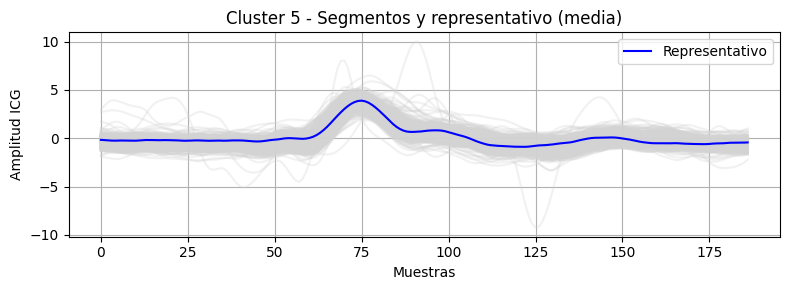

In [38]:
for cluster_id in range(n_clusters):
    cluster_data = df_segments[df_segments['Cluster'] == cluster_id]['Segment']
    segment_matrix = np.stack(cluster_data.values)

    # Calcular la media
    mean_segment = np.mean(segment_matrix, axis=0)

    # Calcular la distancia de cada segmento al promedio
    distances = cdist(segment_matrix, [mean_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

    #Calcular la varianza entre las señales de un mismo cluster
    variance = np.var(segment_matrix, axis=0)
    mean_variance = np.mean(variance)
    print(f"Cluster {cluster_id} - Varianza media entre señales: {mean_variance:.2f}")

    # Plot
    plt.figure(figsize=(8, 3))
    for segment in segment_matrix:
        plt.plot(segment, color='lightgray', alpha=0.3)

    plt.plot(representative_segment, color='blue', linewidth=1.5, label='Representativo')
    plt.title(f"Cluster {cluster_id} - Segmentos y representativo (media)")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud ICG")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


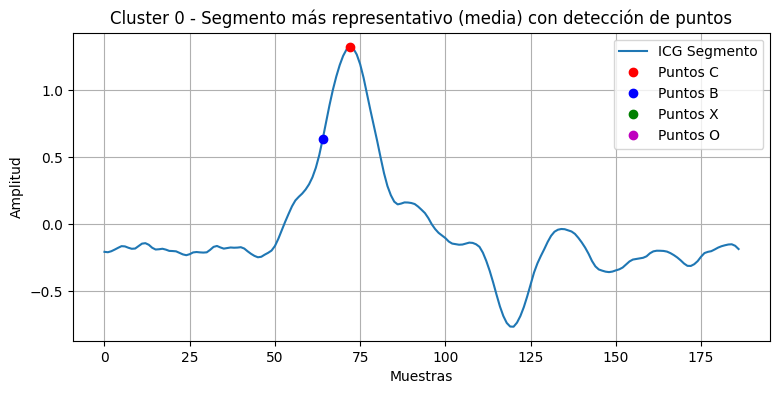

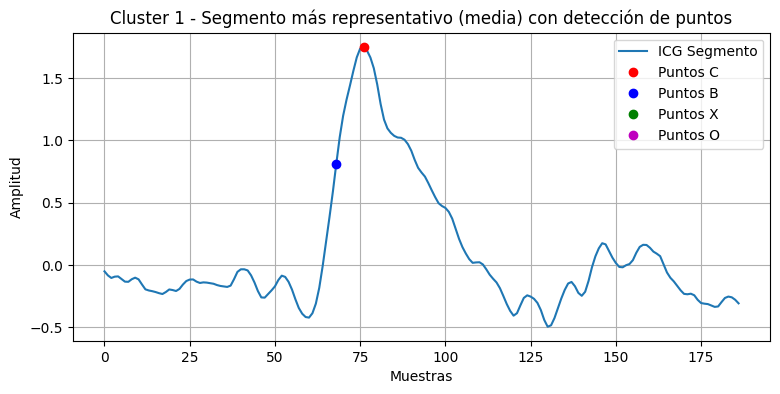

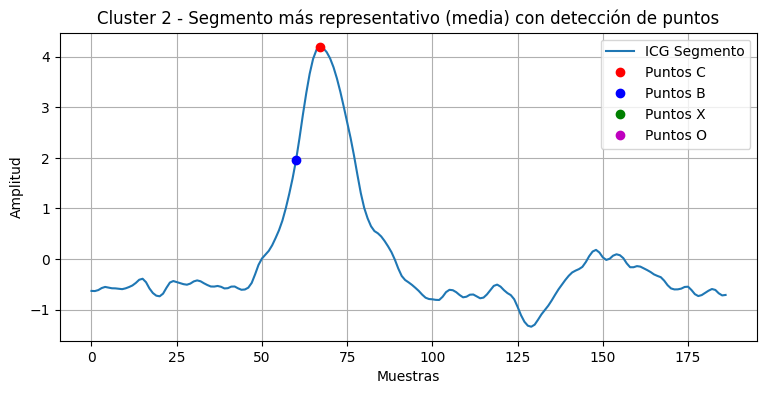

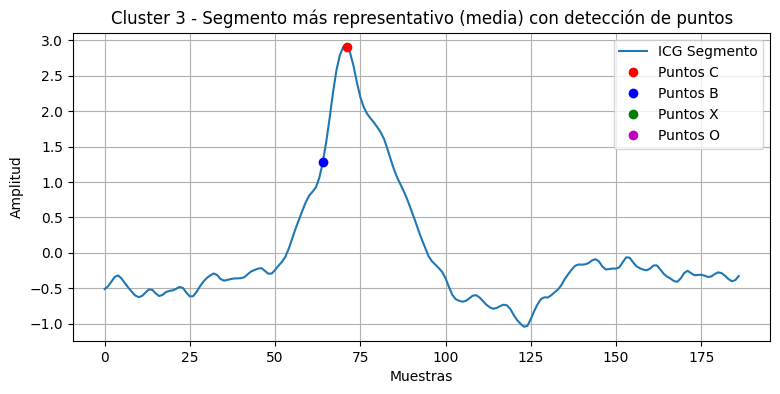

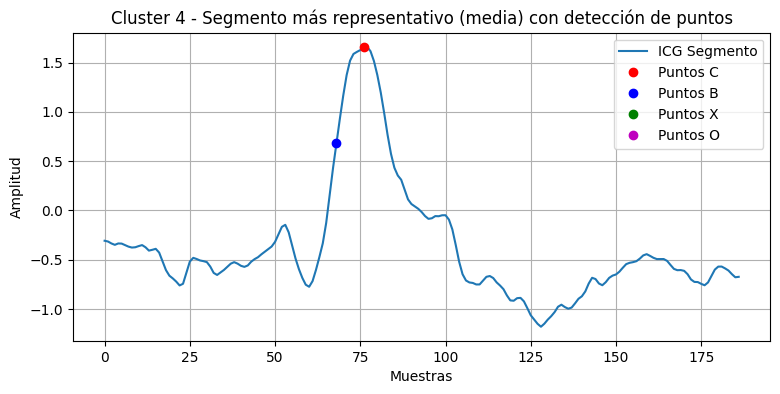

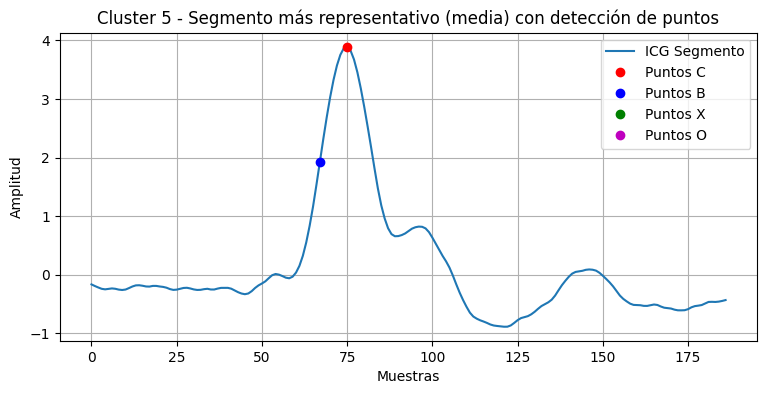

In [39]:
#Representación de curva más representativa de cada cluster en función de la media
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de que df_segments tenga una columna 'Cluster'
# Y que cada fila en la columna 'Segment' contenga un array 1D

n_clusters = df_segments['Cluster'].nunique()

for cluster_id in range(n_clusters):
    cluster_data = df_segments[df_segments['Cluster'] == cluster_id]['Segment']
    segment_matrix = np.stack(cluster_data.values)


    central_segment = np.mean(segment_matrix, axis=0)

    # Calcular la distancia entre cada segmento y el central (media o mediana)
    distances = cdist(segment_matrix, [central_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]
    #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (media) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()


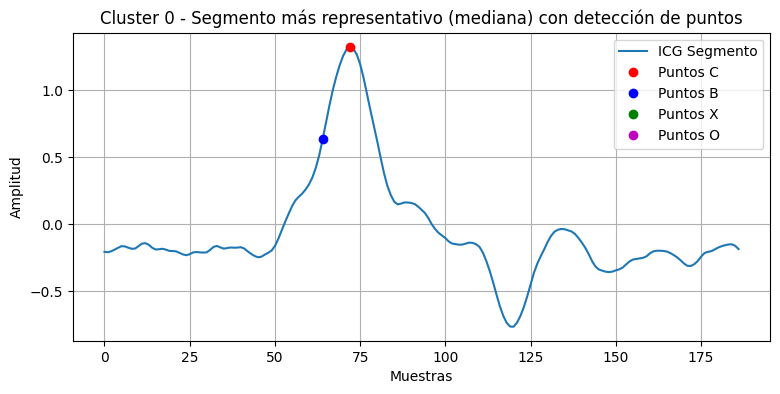

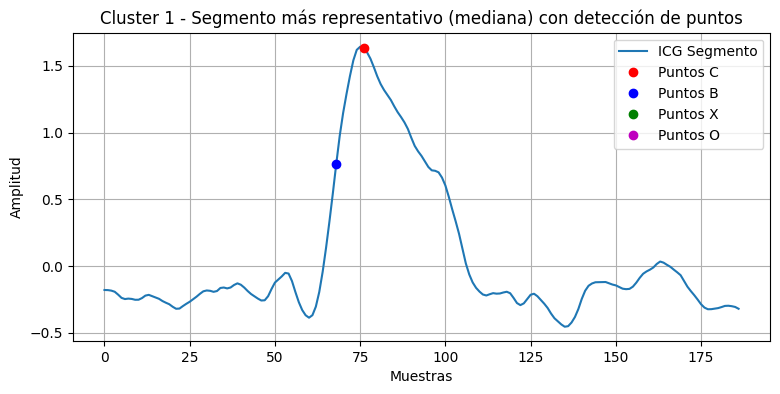

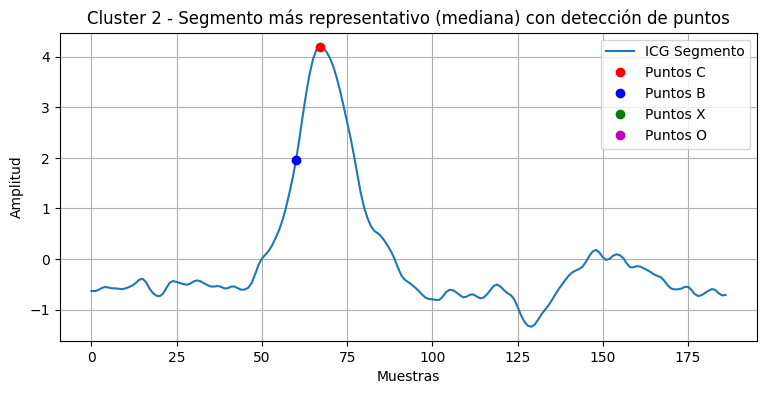

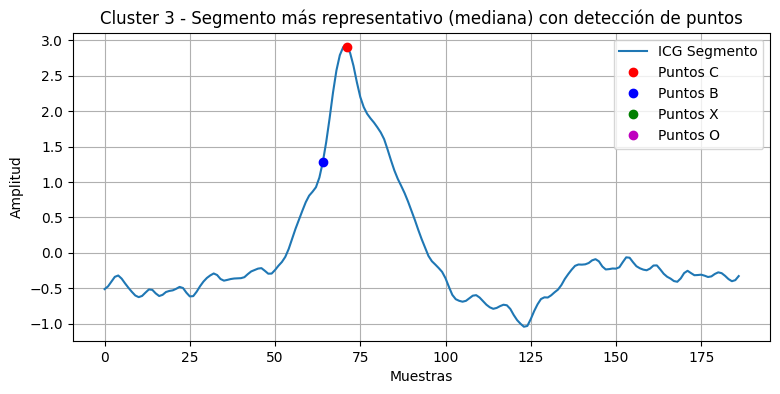

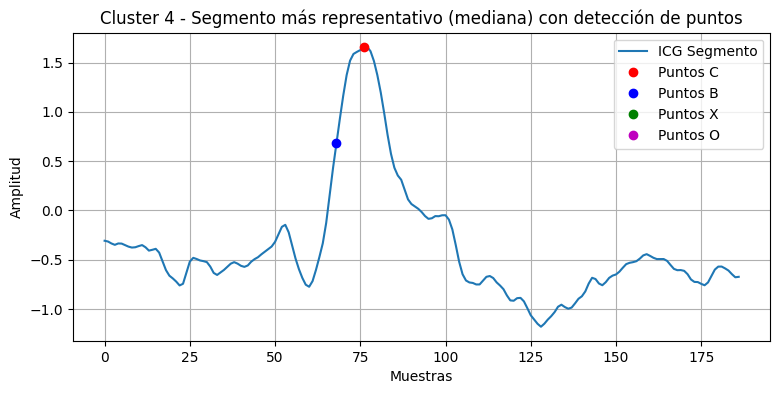

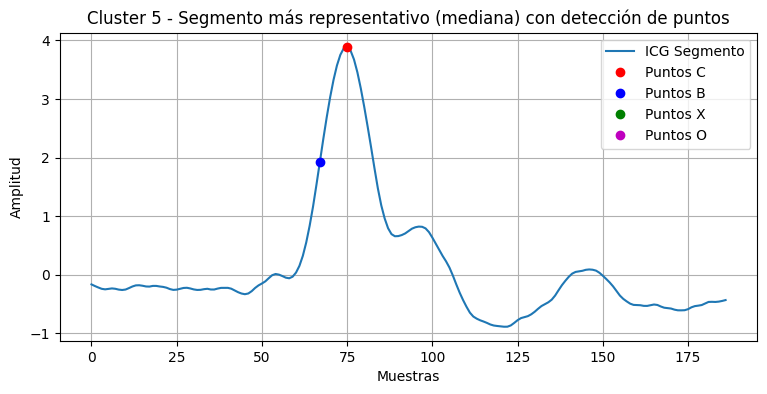

In [40]:
#Representación de curva más representativa de cada cluster en función de la mediana
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de que df_segments tenga una columna 'Cluster'
# Y que cada fila en la columna 'Segment' contenga un array 1D

n_clusters = df_segments['Cluster'].nunique()

for cluster_id in range(n_clusters):
    cluster_data = df_segments[df_segments['Cluster'] == cluster_id]['Segment']
    segment_matrix = np.stack(cluster_data.values)


    central_segment = np.median(segment_matrix, axis=0)

    # Calcular la distancia entre cada segmento y el central (media o mediana)
    distances = cdist(segment_matrix, [central_segment], metric='euclidean')
    closest_idx = np.argmin(distances)
    representative_segment = segment_matrix[closest_idx]

        #Aplicamos ahora el algoritmo de delineación
    fs=250
    C_peaks, Xre = detect_C_peaks(representative_segment, fs)
    B_points = []
    for Cpos in C_peaks:
      B_idx = find_B_point(representative_segment, Cpos, fs)
      B_points.append(B_idx)
    X_points = []
    O_points = []
    for Cpos in C_peaks:
      X, O = find_XO_points(representative_segment, Cpos, fs)
      X_points.append(X)
      O_points.append(O)
    plt.figure(figsize=(9, 4))
    plt.plot(representative_segment, label="ICG Segmento")
    plt.plot(C_peaks, representative_segment[C_peaks], 'ro', label="Puntos C")
    plt.plot(B_points, representative_segment[B_points], 'bo', label="Puntos B")
    plt.plot(X_points, [representative_segment[x] if x is not None else np.nan for x in X_points], 'go', label="Puntos X")
    plt.plot(O_points, [representative_segment[o] if o is not None else np.nan for o in O_points], 'mo', label="Puntos O")
    plt.legend()
    plt.title(f"Cluster {cluster_id} - Segmento más representativo (mediana) con detección de puntos")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

###Aplicación algoritmo de delineación sobre todos los segmentos

In [10]:
import scipy.io as sio
import numpy as np
import pandas as pd
import neurokit2 as nk
import os
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# ------------------------- FUNCIONES DE DETECCIÓN -------------------------

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)

    for n in range(len(signal)):
        i1 = max(0, n - long_len // 2)
        i2 = min(len(signal), n + long_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)

        j1 = max(0, n - short_len // 2)
        j2 = min(len(signal), n + short_len // 2)
        short_energy = np.sum(signal[j1:j2] ** 2)

        if long_energy != 0:
            c = short_energy / long_energy
            Xre[n] = signal[n] * c
    return Xre

def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)

    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    if len(sorted_peaks) == 0:
        return np.array([]), Xre
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 and sorted_peaks[-2] > np.mean(Xre) else sorted_peaks[-1]

    Thr_max = 0.2 * maxval
    Thr_min = 0.02 * maxval

    C_peaks = []
    active = False
    start_idx = 0

    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active = True
            start_idx = i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if len(C_peaks) == 0 or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    # Filtro de intervalos C-C
    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            avg_cc = np.mean(prev_cc)
            if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                final_C_peaks.append(p)
    return np.array(final_C_peaks), Xre

def find_B_point(icg_segment, Cpos, fs, Afrac=0.5, Bslope1=0.11, Bslope2=0.08):
    BlimL = max(0, int(Cpos - 0.08 * fs))
    C_amp = icg_segment[Cpos]
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * C_amp:
            BlimR = i
            break
    else:
        BlimR = BlimL
    slope = np.gradient(icg_segment)
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and (icg_segment[i] < icg_segment[i-1])) or abs(slope[i]) > Bslope1:
            return i
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i
    search_region = icg_segment[BlimL:BlimR+1]
    return BlimL + np.argmin(search_region)

def find_XO_points(icg_segment, Cpos, fs):
    COmin = int(0.020 * fs)
    COmax = int(0.040 * fs)
    CXmin = int(0.015 * fs)
    CXmax = int(0.030 * fs)

    O_win_start = Cpos + COmin
    O_win_end = min(len(icg_segment), Cpos + COmax)
    O_window = icg_segment[O_win_start:O_win_end]
    O_candidates = O_win_start + argrelextrema(O_window, np.greater)[0]

    X_win_start = Cpos + CXmin
    X_win_end = min(len(icg_segment), Cpos + CXmax)
    X_window = icg_segment[X_win_start:X_win_end]
    X_candidates = X_win_start + argrelextrema(X_window, np.less)[0]

    best_pair = (None, None)
    max_amp_diff = -np.inf

    for X in X_candidates:
        for O in O_candidates:
            if O > X:
                delta_t = (O - X) / fs
                if 0.002 <= delta_t <= 0.015:
                    segment_between = icg_segment[X:O]
                    num_minima = len(argrelextrema(segment_between, np.less)[0])
                    if num_minima < 3:
                        amp_diff = icg_segment[O] - icg_segment[X]
                        if amp_diff > max_amp_diff:
                            max_amp_diff = amp_diff
                            best_pair = (X, O)
    return best_pair

# ------------------------- APLICAR A TODOS LOS SEGMENTOS -------------------------

fs = 250
C_positions = []
B_positions = []
X_positions = []
O_positions = []

for idx, row in df_segments.iterrows():
    segment = row['Segment']
    try:
        # Detectar C
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            C = B = X = O = None
        else:
            C = C_peaks[0]  # Tomamos solo el primero
            B = find_B_point(segment, C, fs)
            X, O = find_XO_points(segment, C, fs)
    except Exception as e:
        print(f"Error en segmento {idx}: {e}")
        C = B = X = O = None

    C_positions.append(C)
    B_positions.append(B)
    X_positions.append(X)
    O_positions.append(O)

# Añadir columnas al DataFrame
df_segments['C_pos'] = C_positions
df_segments['B_pos'] = B_positions
df_segments['X_pos'] = X_positions
df_segments['O_pos'] = O_positions

# Guardar resultado
df_segments.to_csv("icg_segments_delineated.csv", index=False)


